# Juan David Alvarez
# Análisis de Sentimientos en Reseñas  Experimento Comparativo Multi-Dataset

# 1. Introducción y Objetivo

El análisis de sentimientos es una de las tareas más estudiadas dentro del Procesamiento
de Lenguaje Natural (NLP). Consiste en identificar automáticamente la polaridad emocional
de un texto — en este caso, determinar si una reseña expresa una opinión **positiva** o
**negativa**.

### Datasets
Este notebook trabaja con dos fuentes de datos de naturaleza distinta:

| Dataset | Fuente | Tamaño | Dominio | Estado inicial |
|---|---|---|---|---|
| IMDB Movie Reviews | Kaggle | 50.000 reseñas | Películas | Limpio, binario |
| Yelp Reviews | Kaggle | ~7M reseñas (muestra de 100k) | Restaurantes/negocios | Sucio, rating 1-5 |

La diferencia entre ambos es intencional: el IMDB sirve como **baseline limpio** mientras
que el Yelp permite ejercitar un pipeline realista de limpieza, binarización y balanceo
de datos — situación más cercana a lo que se encuentra en proyectos reales.

### Enfoque experimental — Tres fases
En lugar de entrenar un único modelo sobre un único dataset, este notebook adopta un
diseño experimental de **tres fases progresivas**:

- **Fase 1:** Modelos entrenados sobre IMDB (baseline limpio)
- **Fase 2:** Modelos entrenados sobre Yelp (después del pipeline de limpieza)
- **Fase 3:** Modelos entrenados sobre IMDB + Yelp combinados

Este diseño apunta a responder preguntas que un experimento simple no podría:
- ¿Qué tanto impacta la calidad del dato en el rendimiento del modelo?
- ¿Mezclar dominios diferentes (películas vs restaurantes) mejora o perjudica?
- ¿Se beneficia el LSTM de más datos más que los modelos clásicos?

### Matriz de experimentos
Cada fase evalúa cinco configuraciones, para un total de **15 experimentos comparables**:

| Vectorización | Modelo |
|---|---|
| Bag of Words | Naive Bayes |
| Bag of Words | Logistic Regression |
| TF-IDF | Naive Bayes |
| TF-IDF | Logistic Regression |
| Embeddings (Keras) | LSTM |

### Métricas de evaluación
Se reportarán **Accuracy**, **Precision**, **Recall**, **F1-Score** y **tiempo de
entrenamiento** para cada configuración.

# 2. Importación de librerias

In [2]:

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Procesamiento de texto
import re
import time
import warnings
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Vectorización
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Modelos clásicos
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluación
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score,
                             classification_report)

# Balanceo
from imblearn.under_sampling import RandomUnderSampler

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')

# Descargas NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')



[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

# 3. Carga y exploración inicial de los datos

In [3]:

# IMDB 

df_imdb = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

print("=" * 50)
print("IMDB Dataset")
print("=" * 50)
print(f"Shape: {df_imdb.shape}")
print(f"\nColumnas: {df_imdb.columns.tolist()}")
print(f"\nValores nulos:\n{df_imdb.isnull().sum()}")
print(f"\nDistribución de clases:\n{df_imdb['sentiment'].value_counts()}")

df_imdb.head(3)

# Conversión de etiquetas IMDB a numérico
df_imdb['label'] = df_imdb['sentiment'].map({'positive': 1, 'negative': 0})
df_imdb.head(3)

IMDB Dataset
Shape: (50000, 2)

Columnas: ['review', 'sentiment']

Valores nulos:
review       0
sentiment    0
dtype: int64

Distribución de clases:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment,label
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1


In [4]:
# YELP
import json
from collections import defaultdict

CUOTA_POR_RATING = 20_000
MUESTRA_ALEATORIA = 20_000  # filas para mostrar el desbalance real
RUTA_YELP = '/kaggle/input/datasets/organizations/yelp-dataset/yelp-dataset/yelp_academic_dataset_review.json'

# ── Paso 1: Muestra aleatoria para visualizar el desbalance real ──
# Antes de aplicar cualquier estrategia de muestreo, se toman
# las primeras 20k filas del JSON para mostrar cómo se distribuyen
# los ratings en el dataset original — sin ningún filtro.

print("Paso 1 — Leyendo muestra aleatoria para diagnóstico de desbalance...")

muestra_raw = []
with open(RUTA_YELP, 'r', encoding='utf-8') as f:
    for i, linea in enumerate(f):
        if i >= MUESTRA_ALEATORIA:
            break
        registro = json.loads(linea)
        muestra_raw.append({'stars': registro['stars']})

df_muestra_diagnostico = pd.DataFrame(muestra_raw)

print(f"Muestra leída: {len(df_muestra_diagnostico):,} filas")
print(f"\nDistribución de ratings en muestra aleatoria:")
print(df_muestra_diagnostico['stars'].value_counts().sort_index())

Paso 1 — Leyendo muestra aleatoria para diagnóstico de desbalance...
Muestra leída: 20,000 filas

Distribución de ratings en muestra aleatoria:
stars
1.0    2157
2.0    1571
3.0    2241
4.0    5130
5.0    8901
Name: count, dtype: int64


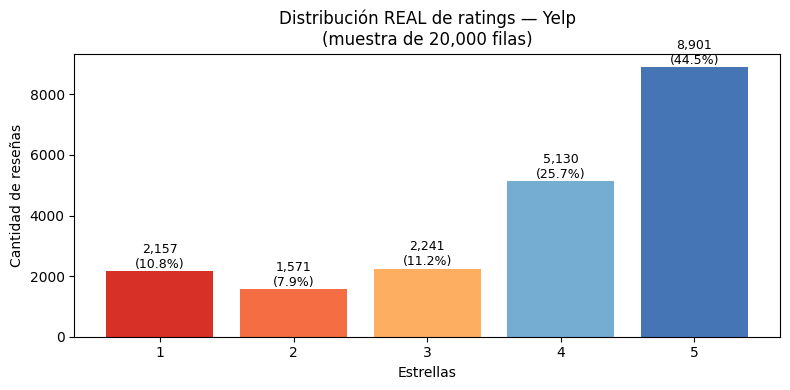


Métricas de desbalance:
  Rating más frecuente  : 5.0 estrellas (8,901 reseñas)
  Rating menos frecuente: 2.0 estrellas (1,571 reseñas)
  Ratio de desbalance   : 5.7:1

→ Un ratio de 5.7:1 justifica el muestreo estratificado
  Un modelo entrenado sobre esta distribución tendería a predecir
  ratings altos por simple mayoría, no por aprendizaje real


In [5]:
# Visualización del desbalance real
fig, ax = plt.subplots(figsize=(8, 4))

conteo = df_muestra_diagnostico['stars'].value_counts().sort_index()
bars = ax.bar(conteo.index, conteo.values,
              color=['#d73027', '#f46d43', '#fdae61', '#74add1', '#4575b4'])
ax.set_title(f'Distribución REAL de ratings — Yelp\n(muestra de {MUESTRA_ALEATORIA:,} filas)')
ax.set_xlabel('Estrellas')
ax.set_ylabel('Cantidad de reseñas')

for bar, val in zip(bars, conteo.values):
    pct = val / len(df_muestra_diagnostico) * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

mayoria = conteo.max()
minoria = conteo.min()
print(f"\nMétricas de desbalance:")
print(f"  Rating más frecuente  : {conteo.idxmax()} estrellas ({mayoria:,} reseñas)")
print(f"  Rating menos frecuente: {conteo.idxmin()} estrellas ({minoria:,} reseñas)")
print(f"  Ratio de desbalance   : {mayoria/minoria:.1f}:1")
print(f"\n→ Un ratio de {mayoria/minoria:.1f}:1 justifica el muestreo estratificado")
print(f"  Un modelo entrenado sobre esta distribución tendería a predecir")
print(f"  ratings altos por simple mayoría, no por aprendizaje real")

In [6]:
# ──Muestreo estratificado por rating ──────────────────
print("\n Leyendo dataset con muestreo estratificado...")
print(f"Cuota por rating: {CUOTA_POR_RATING:,} reseñas")
print(f"Total máximo a cargar: {CUOTA_POR_RATING * 5:,} filas\n")

buckets = defaultdict(list)
total_leidas = 0

with open(RUTA_YELP, 'r', encoding='utf-8') as f:
    for linea in f:
        total_leidas += 1
        registro = json.loads(linea)
        stars = registro['stars']

        if len(buckets[stars]) < CUOTA_POR_RATING:
            buckets[stars].append({
                'stars'  : registro['stars'],
                'useful' : registro['useful'],
                'cool'   : registro['cool'],
                'text'   : registro['text']
            })

        if all(len(buckets[s]) >= CUOTA_POR_RATING for s in [1, 2, 3, 4, 5]):
            break

print(f"Líneas leídas del JSON: {total_leidas:,}")
print(f"\nReseñas recolectadas por rating:")
for star in sorted(buckets.keys()):
    print(f"  {star} estrella(s): {len(buckets[star]):,}")


 Leyendo dataset con muestreo estratificado...
Cuota por rating: 20,000 reseñas
Total máximo a cargar: 100,000 filas

Líneas leídas del JSON: 248,748

Reseñas recolectadas por rating:
  1 estrella(s): 20,000
  2.0 estrella(s): 20,000
  3.0 estrella(s): 20,000
  4.0 estrella(s): 20,000
  5.0 estrella(s): 20,000


In [7]:
# Convertir a DataFrame
df_yelp_raw = pd.DataFrame([
    r for star in sorted(buckets.keys()) for r in buckets[star]
])

print(f"\nShape del DataFrame: {df_yelp_raw.shape}")
print(f"\nColumnas: {df_yelp_raw.columns.tolist()}")
print(f"\nTipos de datos:\n{df_yelp_raw.dtypes}")
df_yelp_raw.head(3)

# Guardar como CSV para reproducibilidad
RUTA_CSV = '/kaggle/working/yelp_muestra.csv'
df_yelp_raw.to_csv(RUTA_CSV, index=False)

import os
tam_mb = os.path.getsize(RUTA_CSV) / (1024 * 1024)
print(f"✓ Muestra guardada en: {RUTA_CSV}")
print(f"  Tamaño en disco: {tam_mb:.1f} MB")


Shape del DataFrame: (100000, 4)

Columnas: ['stars', 'useful', 'cool', 'text']

Tipos de datos:
stars     float64
useful      int64
cool        int64
text       object
dtype: object
✓ Muestra guardada en: /kaggle/working/yelp_muestra.csv
  Tamaño en disco: 58.9 MB


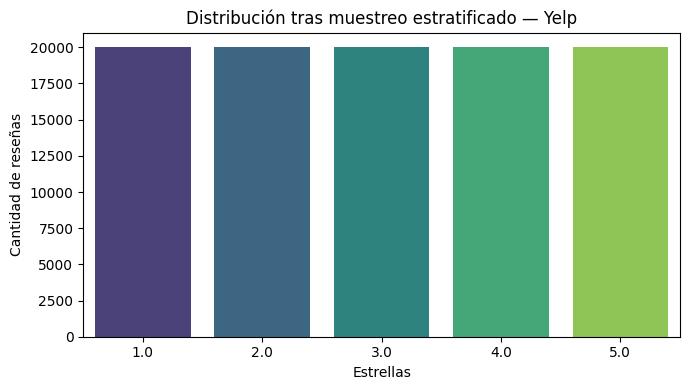

Distribución balanceada por diseño:
stars
1.0    20000
2.0    20000
3.0    20000
4.0    20000
5.0    20000
Name: count, dtype: int64


In [8]:
# Verificación visual — distribución después del muestreo
fig, ax = plt.subplots(figsize=(7, 4))

sns.countplot(x='stars', data=df_yelp_raw, palette='viridis', ax=ax)
ax.set_title('Distribución tras muestreo estratificado — Yelp')
ax.set_xlabel('Estrellas')
ax.set_ylabel('Cantidad de reseñas')

plt.tight_layout()
plt.show()

print("Distribución balanceada por diseño:")
print(df_yelp_raw['stars'].value_counts().sort_index())

In [9]:
# Diagnóstico inicial de calidad
print("=" * 50)
print("DIAGNÓSTICO RÁPIDO DE CALIDAD — YELP")
print("=" * 50)

nulos = df_yelp_raw.isnull().sum()
print(f"\n1. Valores nulos por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "   → No se encontraron nulos")

dups = df_yelp_raw.duplicated().sum()
dups_text = df_yelp_raw.duplicated(subset=['text']).sum()
print(f"\n2. Filas duplicadas      : {dups}")
print(f"   Duplicados por texto  : {dups_text}")

df_yelp_raw['review_length'] = df_yelp_raw['text'].apply(
    lambda x: len(str(x).split()) if pd.notnull(x) else 0
)
muy_cortas = (df_yelp_raw['review_length'] < 3).sum()
print(f"\n3. Reseñas < 3 palabras : {muy_cortas}")

print(f"\n4. Distribución de votos 'useful':")
print(f"   Con useful = 0  : {(df_yelp_raw['useful'] == 0).sum():,}")
print(f"   Con useful >= 1 : {(df_yelp_raw['useful'] >= 1).sum():,}")

print(f"\n5. Distribución de votos 'cool':")
print(f"   Con cool = 0    : {(df_yelp_raw['cool'] == 0).sum():,}")
print(f"   Con cool >= 1   : {(df_yelp_raw['cool'] >= 1).sum():,}")

print(f"\n{'='*50}")
print("Problemas a resolver en Sección 5:")
print(f"{'='*50}")
problemas = [
    "✗ Rating numérico (1-5) requiere binarización",
    "✗ Rating 3 estrellas será descartado (sentimiento ambiguo)",
    "✗ Desbalance residual tras binarización → undersampling"
]
if nulos.sum() > 0: problemas.insert(0, "✗ Valores nulos presentes")
if dups > 0: problemas.insert(0, "✗ Filas duplicadas")
if muy_cortas > 0: problemas.insert(0, "✗ Reseñas demasiado cortas")
for p in problemas:
    print(f"  {p}")

DIAGNÓSTICO RÁPIDO DE CALIDAD — YELP

1. Valores nulos por columna:
   → No se encontraron nulos

2. Filas duplicadas      : 30
   Duplicados por texto  : 63

3. Reseñas < 3 palabras : 5

4. Distribución de votos 'useful':
   Con useful = 0  : 56,939
   Con useful >= 1 : 43,061

5. Distribución de votos 'cool':
   Con cool = 0    : 82,287
   Con cool >= 1   : 17,713

Problemas a resolver en Sección 5:
  ✗ Reseñas demasiado cortas
  ✗ Filas duplicadas
  ✗ Rating numérico (1-5) requiere binarización
  ✗ Rating 3 estrellas será descartado (sentimiento ambiguo)
  ✗ Desbalance residual tras binarización → undersampling


# 4. Análisis Exploratorio de Datos (EDA)

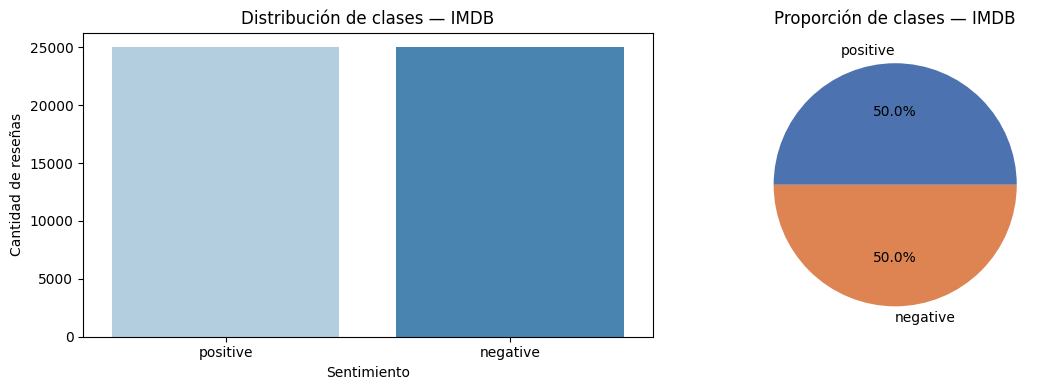

Balance de clases:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Proporción:
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64


In [10]:
# EDA — IMDB 

# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
sns.countplot(x='sentiment', data=df_imdb, palette='Blues', ax=axes[0])
axes[0].set_title('Distribución de clases — IMDB')
axes[0].set_xlabel('Sentimiento')
axes[0].set_ylabel('Cantidad de reseñas')

# Proporción
df_imdb['sentiment'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    ax=axes[1]
)
axes[1].set_title('Proporción de clases — IMDB')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"Balance de clases:\n{df_imdb['sentiment'].value_counts()}")
print(f"\nProporción:\n{df_imdb['sentiment'].value_counts(normalize=True).round(3)}")

Estadísticas de longitud (en palabras):
count    50000.00
mean       231.16
std        171.34
min          4.00
25%        126.00
50%        173.00
75%        280.00
max       2470.00
Name: review_length, dtype: float64


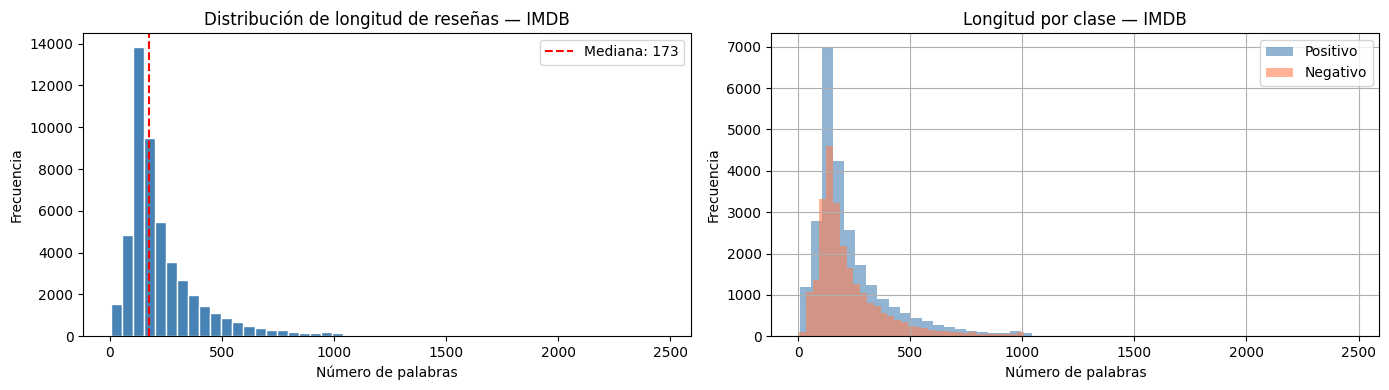


Percentil 95 de longitud: 590 palabras
→ Se usará max_length=590 para el padding del LSTM


In [11]:
# Análisis de longitud de reseñas
df_imdb['review_length'] = df_imdb['review'].apply(lambda x: len(x.split()))

print("Estadísticas de longitud (en palabras):")
print(df_imdb['review_length'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución general
axes[0].hist(df_imdb['review_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de longitud de reseñas — IMDB')
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df_imdb['review_length'].median(), color='red',
                linestyle='--', label=f"Mediana: {df_imdb['review_length'].median():.0f}")
axes[0].legend()

# Por clase
df_imdb[df_imdb['sentiment'] == 'positive']['review_length'].hist(
    bins=50, alpha=0.6, color='steelblue', label='Positivo', ax=axes[1])
df_imdb[df_imdb['sentiment'] == 'negative']['review_length'].hist(
    bins=50, alpha=0.6, color='coral', label='Negativo', ax=axes[1])
axes[1].set_title('Longitud por clase — IMDB')
axes[1].set_xlabel('Número de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

# Este análisis informa el parámetro max_length del LSTM
percentil_95 = df_imdb['review_length'].quantile(0.95)
print(f"\nPercentil 95 de longitud: {percentil_95:.0f} palabras")
print(f"→ Se usará max_length={int(percentil_95)} para el padding del LSTM")

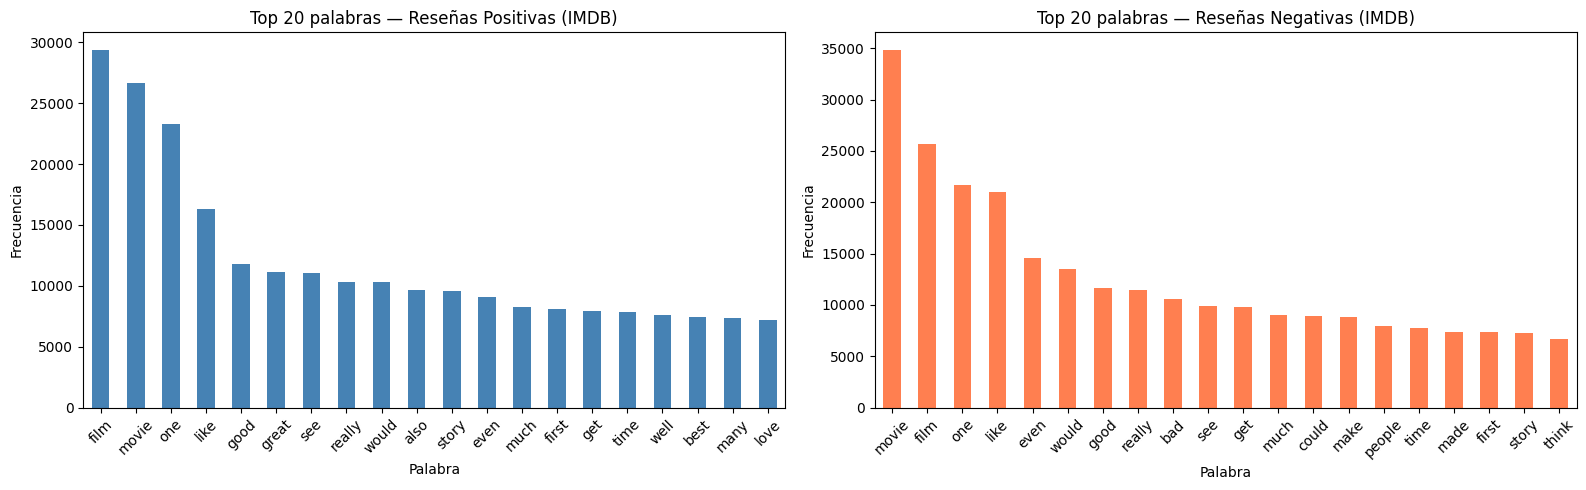

In [12]:
# Palabras más frecuentes por clase — IMDB
stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        tokens = str(text).lower().split()
        words.extend([w for w in tokens if w not in stop_words and w.isalpha()])
    freq = pd.Series(words).value_counts().head(n)
    return freq

top_pos = get_top_words(df_imdb[df_imdb['sentiment'] == 'positive']['review'])
top_neg = get_top_words(df_imdb[df_imdb['sentiment'] == 'negative']['review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_pos.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 palabras — Reseñas Positivas (IMDB)')
axes[0].set_xlabel('Palabra')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=45)

top_neg.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top 20 palabras — Reseñas Negativas (IMDB)')
axes[1].set_xlabel('Palabra')
axes[1].set_ylabel('Frecuencia')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

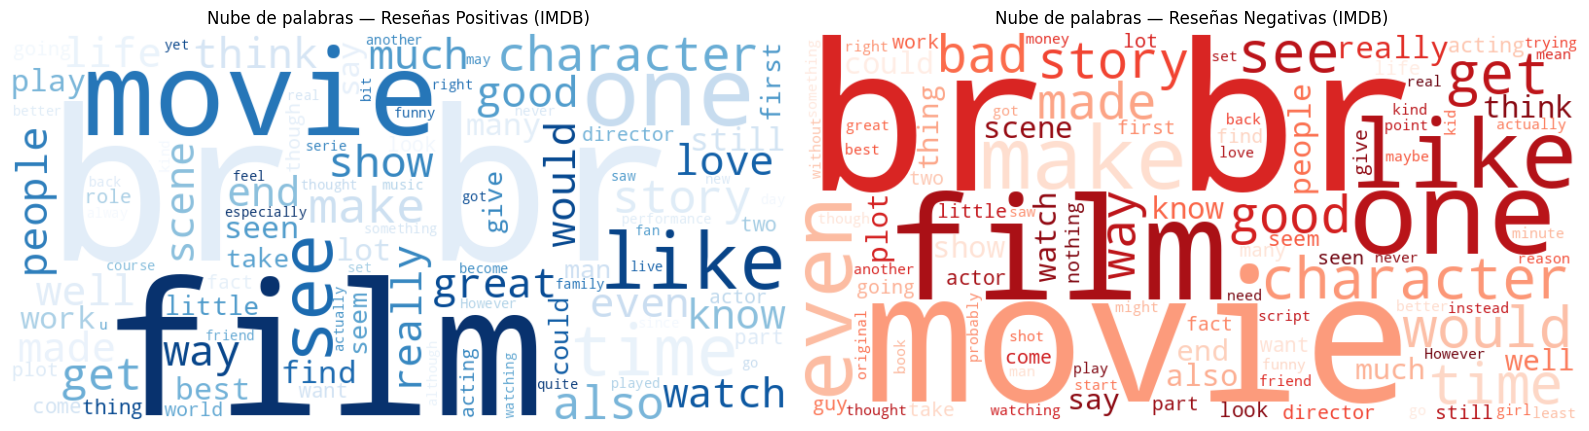

In [86]:
# Nubes de palabras — IMDB
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, sentiment, color, label in zip(
    axes,
    ['positive', 'negative'],
    ['Blues', 'Reds'],
    ['Positivas', 'Negativas']
):
    text = ' '.join(df_imdb[df_imdb['sentiment'] == sentiment]['review'].astype(str))
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=color,
        stopwords=stop_words,
        max_words=100
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Nube de palabras — Reseñas {label} (IMDB)')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# Diagnóstico completo de calidad — Yelp
print("=" * 50)
print("DIAGNÓSTICO DE CALIDAD — YELP")
print("=" * 50)

df_yelp = df_yelp_raw
# Nulos
nulos = df_yelp.isnull().sum()
print(f"\n1. Valores nulos por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "   → No se encontraron nulos")

# Duplicados
dups = df_yelp.duplicated().sum()
print(f"\n2. Filas duplicadas: {dups}")

# Duplicados solo por texto
dups_text = df_yelp.duplicated(subset=['text']).sum()
print(f"   Duplicados por texto: {dups_text}")

# Reseñas muy cortas
df_yelp['review_length'] = df_yelp['text'].apply(
    lambda x: len(str(x).split()) if pd.notnull(x) else 0
)
muy_cortas = (df_yelp['review_length'] < 3).sum()
print(f"\n3. Reseñas con menos de 3 palabras: {muy_cortas}")

# Valores únicos en stars
print(f"\n4. Valores únicos en 'stars': {sorted(df_yelp['stars'].unique())}")

# Columnas relevantes vs irrelevantes
print(f"\n5. Columnas disponibles: {df_yelp.columns.tolist()}")
print(f"   → Para este ejercicio solo se usarán: ['text', 'stars']")
print(f"   → El resto serán descartadas en el preprocesamiento")

print("\n" + "=" * 50)
print("Resumen: problemas identificados a resolver en Sección 5")
print("=" * 50)
problemas = []
if nulos.sum() > 0: problemas.append("✗ Valores nulos presentes")
if dups > 0: problemas.append("✗ Filas duplicadas")
if muy_cortas > 0: problemas.append("✗ Reseñas demasiado cortas")
problemas.append("✗ Rating numérico (1-5) requiere binarización")
problemas.append("✗ Posible desbalance tras binarización")
for p in problemas:
    print(p)

DIAGNÓSTICO DE CALIDAD — YELP

1. Valores nulos por columna:
   → No se encontraron nulos

2. Filas duplicadas: 30
   Duplicados por texto: 63

3. Reseñas con menos de 3 palabras: 5

4. Valores únicos en 'stars': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

5. Columnas disponibles: ['stars', 'useful', 'cool', 'text', 'review_length']
   → Para este ejercicio solo se usarán: ['text', 'stars']
   → El resto serán descartadas en el preprocesamiento

Resumen: problemas identificados a resolver en Sección 5
✗ Filas duplicadas
✗ Reseñas demasiado cortas
✗ Rating numérico (1-5) requiere binarización
✗ Posible desbalance tras binarización


Estadísticas de longitud (en palabras) — Yelp:
count    100000.00
mean        112.53
std         101.93
min           1.00
25%          46.00
50%          82.00
75%         144.00
max        1006.00
Name: review_length, dtype: float64


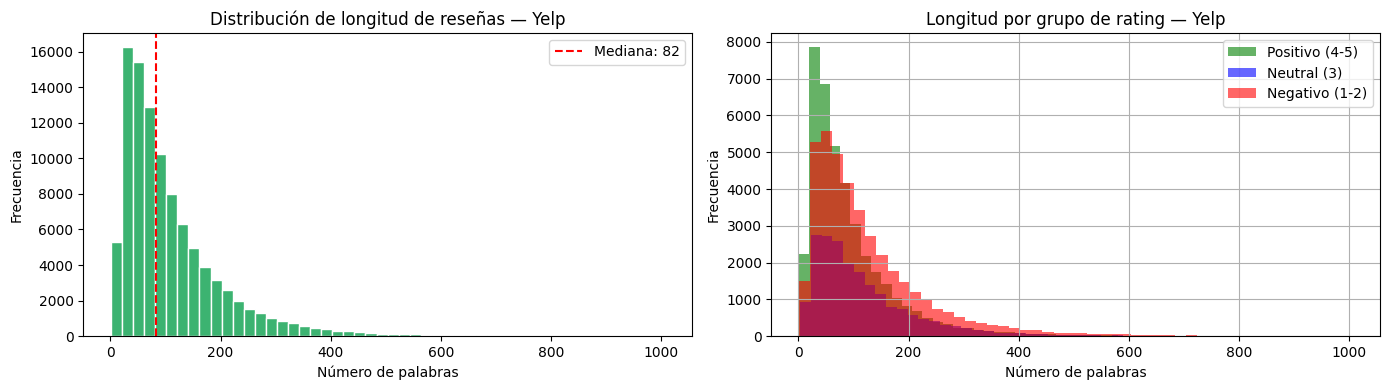

Comparación de longitud promedio entre datasets:
  IMDB  → media: 231 | mediana: 173 palabras
  Yelp  → media: 113 | mediana: 82 palabras

→ Esta diferencia impacta el parámetro max_length del LSTM
  Se tomará el percentil 95 del dataset combinado como referencia


In [14]:
# Análisis de longitud — Yelp
print("Estadísticas de longitud (en palabras) — Yelp:")
print(df_yelp_raw['review_length'].describe().round(2))

# Agrupación por sentimiento para el segundo gráfico
df_yelp_raw['grupo'] = df_yelp_raw['stars'].apply(
    lambda x: 'Positivo (4-5)' if x >= 4 else ('Neutral (3)' if x == 3 else 'Negativo (1-2)')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico 1 — Distribución general
axes[0].hist(df_yelp_raw['review_length'], bins=50,
             color='mediumseagreen', edgecolor='white')
axes[0].set_title('Distribución de longitud de reseñas — Yelp')
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df_yelp_raw['review_length'].median(), color='red',
                linestyle='--',
                label=f"Mediana: {df_yelp_raw['review_length'].median():.0f}")
axes[0].legend()

# Gráfico 2 — Por grupo de rating
for grupo, color in zip(
    ['Positivo (4-5)', 'Neutral (3)', 'Negativo (1-2)'],
    ['green', 'blue', 'red']
):
    df_yelp_raw[df_yelp_raw['grupo'] == grupo]['review_length'].hist(
        bins=50, alpha=0.6, color=color, label=grupo, ax=axes[1])

axes[1].set_title('Longitud por grupo de rating — Yelp')
axes[1].set_xlabel('Número de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

# Comparación entre datasets 
print("Comparación de longitud promedio entre datasets:")
print(f"  IMDB  → media: {df_imdb['review_length'].mean():.0f} | "
      f"mediana: {df_imdb['review_length'].median():.0f} palabras")
print(f"  Yelp  → media: {df_yelp_raw['review_length'].mean():.0f} | "
      f"mediana: {df_yelp_raw['review_length'].median():.0f} palabras")
print(f"\n→ Esta diferencia impacta el parámetro max_length del LSTM")
print(f"  Se tomará el percentil 95 del dataset combinado como referencia")


# 5. Preprocesamiento

In [46]:
# Función de limpieza de texto
lemmatizer = WordNetLemmatizer()
stop_words_en = set(stopwords.words('english'))

def clean_text(text):
    # 1. Eliminar etiquetas HTML (el IMDB tiene <br /> frecuentemente)
    text = re.sub(r'<.*?>', ' ', str(text))
    # 2. Eliminar URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # 3. Eliminar caracteres especiales y números
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # 4. Lowercase
    text = text.lower()
    # 5. Tokenizar
    tokens = text.split()
    # 6.Solo lematizar; no eliminar stopwords
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if len(w) > 2
    ]    
    return ' '.join(tokens)


print("Aplicando limpieza al IMDB...")
start = time.time()
df_imdb['clean_review'] = df_imdb['review'].apply(clean_text)
print(f"✓ Completado en {time.time() - start:.1f} segundos")

# Verificación
print("\nEjemplo antes y después de la limpieza:")
idx = 0
print(f"\nOriginal:\n{df_imdb['review'].iloc[idx][:300]}...")
print(f"\nLimpio:\n{df_imdb['clean_review'].iloc[idx][:300]}...")

Aplicando limpieza al IMDB...
✓ Completado en 44.8 segundos

Ejemplo antes y después de la limpieza:

Original:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru...

Limpio:
one the other reviewer ha mentioned that after watching just episode you hooked they are right this exactly what happened with the first thing that struck about wa it brutality and unflinching scene violence which set right from the word trust this not show for the faint hearted timid this show pull...


In [49]:
# Verificación post-limpieza IMDB
print("=" * 50)
print("VERIFICACIÓN POST-LIMPIEZA — IMDB")
print("=" * 50)

# Reseñas vacías después de limpiar
vacias = df_imdb['clean_review'].str.strip().eq('').sum()
print(f"Reseñas vacías tras limpieza: {vacias}")

# Longitud después de limpieza
df_imdb['clean_length'] = df_imdb['clean_review'].apply(lambda x: len(x.split()))
print(f"\nLongitud promedio antes: {df_imdb['review_length'].mean():.0f} palabras")
print(f"Longitud promedio después: {df_imdb['clean_length'].mean():.0f} palabras")
print(f"Reducción: {(1 - df_imdb['clean_length'].mean()/df_imdb['review_length'].mean())*100:.1f}%")

print(f"\nShape final IMDB: {df_imdb[['clean_review','label']].dropna().shape}")
print("✓ IMDB listo para vectorización")

VERIFICACIÓN POST-LIMPIEZA — IMDB
Reseñas vacías tras limpieza: 0

Longitud promedio antes: 231 palabras
Longitud promedio después: 182 palabras
Reducción: 21.4%

Shape final IMDB: (50000, 2)
✓ IMDB listo para vectorización


In [50]:
print("pipeline para limpieza de datos de YELP \n")
print("Paso 1 — Selección de columnas relevantes")
df_yelp = df_yelp_raw[['text', 'stars', 'useful']].copy()
print(f"Columnas conservadas: {df_yelp.columns.tolist()}")
print(f"Shape: {df_yelp.shape}")
print(f"\n→ Se conserva 'useful' temporalmente para el filtro de calidad")
print(f"  en el Paso 3. Será descartada después.")

print("\nPaso 2 — Eliminación de nulos y duplicados")

nulos_antes = df_yelp.isnull().sum().sum()
df_yelp = df_yelp.dropna()
print(f"Filas eliminadas por nulos     : {nulos_antes}")

dups_antes = len(df_yelp)
df_yelp = df_yelp.drop_duplicates(subset=['text'])
print(f"Filas eliminadas por duplicados: {dups_antes - len(df_yelp)}")
print(f"Shape: {df_yelp.shape}")

print("\nPaso 3 — Filtro de calidad por votos 'useful'")
print("\nCriterio: conservar solo reseñas con useful >= 1")
print("→ Reseñas votadas como útiles por la comunidad tienen")
print("  mayor probabilidad de ser coherentes y bien redactadas")
print("  reduciendo ruido de reseñas spam o incoherentes\n")

antes = len(df_yelp)
df_yelp = df_yelp[df_yelp['useful'] >= 1].copy()
eliminadas = antes - len(df_yelp)
print(f"Filas eliminadas por useful < 1: {eliminadas:,} ({eliminadas/antes*100:.1f}%)")
print(f"Shape: {df_yelp.shape}")

df_yelp = df_yelp.drop(columns=['useful'])
print(f"\n→ Columna 'useful' descartada tras aplicar el filtro")

print("\nPaso 4 — Eliminación de reseñas con menos de 3 palabras")

df_yelp['review_length'] = df_yelp['text'].apply(lambda x: len(str(x).split()))
cortas_antes = len(df_yelp)
df_yelp = df_yelp[df_yelp['review_length'] >= 3]
print(f"Filas eliminadas: {cortas_antes - len(df_yelp)}")
print(f"Shape: {df_yelp.shape}")

print("\nPaso 5 — Binarización de ratings")
print("\nCriterio de binarización:")
print("  1-2 estrellas → negativo (0)")
print("  3   estrellas → DESCARTADO (sentimiento ambiguo)")
print("  4-5 estrellas → positivo (1)")

antes = len(df_yelp)
df_yelp = df_yelp[df_yelp['stars'] != 3].copy()
df_yelp['label'] = df_yelp['stars'].apply(lambda x: 1 if x >= 4 else 0)

descartadas = antes - len(df_yelp)
print(f"\nFilas descartadas (rating=3): {descartadas:,}")
print(f"Shape: {df_yelp.shape}")
print(f"\nDistribución tras binarización:")
print(df_yelp['label'].value_counts())
print(f"\nProporción:")
print(df_yelp['label'].value_counts(normalize=True).round(3))
print(f"\n→ Gracias al muestreo estratificado de la Sección 3.2")
print(f"  las clases quedan naturalmente balanceadas tras descartar el 3")

print("\nPaso 6 — Verificación de balance")

desbalance = df_yelp['label'].value_counts()
ratio = desbalance.max() / desbalance.min()
print(f"Distribución: {desbalance.to_dict()}")
print(f"Ratio: {ratio:.2f}:1")

if ratio > 1.2:
    print(f"\n→ Ratio > 1.2 — aplicando undersampling")
    min_clase = desbalance.min()
    df_yelp_bal = pd.concat([
        df_yelp[df_yelp['label'] == 0].sample(n=min_clase, random_state=42),
        df_yelp[df_yelp['label'] == 1].sample(n=min_clase, random_state=42)
    ]).reset_index(drop=True)
    print(f"Distribución tras undersampling:\n{df_yelp_bal['label'].value_counts()}")
else:
    print(f"\n→ Ratio <= 1.2 — el dataset está suficientemente balanceado")
    print(f"  No se requiere undersampling")
    df_yelp_bal = df_yelp.reset_index(drop=True)

print(f"\nShape final: {df_yelp_bal.shape}")

print("\nPaso 7 — Limpieza de texto")
print("Aplicando la misma función clean_text usada en IMDB...")
print("→ Reutilizar la misma función garantiza consistencia")
print("  en el preprocesamiento entre ambos datasets\n")

start = time.time()
df_yelp_bal['clean_review'] = df_yelp_bal['text'].apply(clean_text)
print(f"✓ Completado en {time.time() - start:.1f} segundos")

idx = 0
print(f"\nEjemplo antes:\n{df_yelp_bal['text'].iloc[idx][:300]}...")
print(f"\nEjemplo después:\n{df_yelp_bal['clean_review'].iloc[idx][:300]}...")

pipeline para limpieza de datos de YELP 

Paso 1 — Selección de columnas relevantes
Columnas conservadas: ['text', 'stars', 'useful']
Shape: (100000, 3)

→ Se conserva 'useful' temporalmente para el filtro de calidad
  en el Paso 3. Será descartada después.

Paso 2 — Eliminación de nulos y duplicados
Filas eliminadas por nulos     : 0
Filas eliminadas por duplicados: 63
Shape: (99937, 3)

Paso 3 — Filtro de calidad por votos 'useful'

Criterio: conservar solo reseñas con useful >= 1
→ Reseñas votadas como útiles por la comunidad tienen
  mayor probabilidad de ser coherentes y bien redactadas
  reduciendo ruido de reseñas spam o incoherentes

Filas eliminadas por useful < 1: 56,898 (56.9%)
Shape: (43039, 3)

→ Columna 'useful' descartada tras aplicar el filtro

Paso 4 — Eliminación de reseñas con menos de 3 palabras
Filas eliminadas: 1
Shape: (43038, 3)

Paso 5 — Binarización de ratings

Criterio de binarización:
  1-2 estrellas → negativo (0)
  3   estrellas → DESCARTADO (sentimiento a

In [51]:
# Paso 8 — Verificación post-limpieza
print("=" * 50)
print("VERIFICACIÓN POST-LIMPIEZA — YELP")
print("=" * 50)

vacias = df_yelp_bal['clean_review'].str.strip().eq('').sum()
if vacias > 0:
    df_yelp_bal = df_yelp_bal[df_yelp_bal['clean_review'].str.strip() != '']
    print(f"Reseñas vacías tras limpieza eliminadas: {vacias}")
else:
    print("Reseñas vacías tras limpieza: 0 ✓")

print(f"\nNulos restantes: {df_yelp_bal.isnull().sum().sum()} ✓")
print(f"Duplicados restantes: {df_yelp_bal.duplicated(subset=['clean_review']).sum()} ✓")
print(f"\nDistribución final de clases:")
print(df_yelp_bal['label'].value_counts())
print(f"\nShape final Yelp: {df_yelp_bal.shape}")
print("\n✓ Yelp listo para vectorización")

VERIFICACIÓN POST-LIMPIEZA — YELP
Reseñas vacías tras limpieza: 0 ✓

Nulos restantes: 0 ✓
Duplicados restantes: 1 ✓

Distribución final de clases:
label
0    15147
1    15147
Name: count, dtype: int64

Shape final Yelp: (30294, 5)

✓ Yelp listo para vectorización


In [52]:

# IMDB final — solo columnas necesarias
df_imdb_final = df_imdb[['clean_review', 'label']].dropna().reset_index(drop=True)
df_imdb_final['source'] = 'imdb'

# Yelp final — renombrar desde df_yelp_bal
df_yelp_final = df_yelp_bal[['clean_review', 'label']].copy().reset_index(drop=True)
df_yelp_final['source'] = 'yelp'

# Dataset combinado
df_combined = pd.concat(
    [df_imdb_final, df_yelp_final], ignore_index=True
).sample(frac=1, random_state=42).reset_index(drop=True)

# Verificación
print("=" * 50)
print("DATASETS LISTOS PARA LAS TRES FASES")
print("=" * 50)
print(f"\n{'Dataset':<15} {'Filas':<10} {'Positivos':<12} {'Negativos':<12}")
print("-" * 50)
for nombre, df in [("IMDB", df_imdb_final),
                   ("Yelp", df_yelp_final),
                   ("Combinado", df_combined)]:
    pos = (df['label'] == 1).sum()
    neg = (df['label'] == 0).sum()
    print(f"{nombre:<15} {len(df):<10} {pos:<12} {neg:<12}")

DATASETS LISTOS PARA LAS TRES FASES

Dataset         Filas      Positivos    Negativos   
--------------------------------------------------
IMDB            50000      25000        25000       
Yelp            30294      15147        15147       
Combinado       80294      40147        40147       


# 6. Vectorización

 Se preparan dos rutas en paralelo:
   - Ruta A — BoW y TF-IDF (para Naive Bayes y Logistic Regression)
   - Ruta B — Tokenización con padding (para LSTM)

### Importante: cada dataset se vectoriza por separado para evitar contaminación de vocabulario entre fases del experimento.

Parámetros globales de vectorización:
  MAX_LENGTH  : 410 tokens  (percentil 95 del corpus combinado)
  MAX_FEATURES: 10000 palabras en vocabulario
  EMBEDDING_DIM: 64 dimensiones


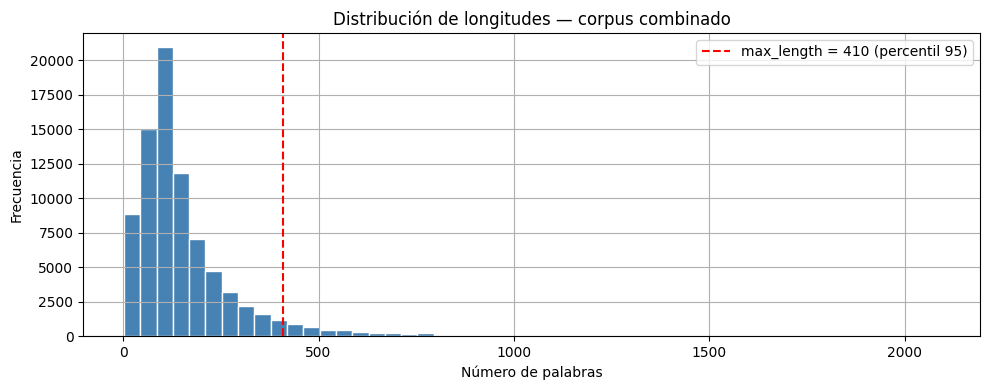

In [53]:
# Definir max_length para el LSTM basándose en el EDA
# Se usa el percentil 95 del dataset combinado como referencia
all_lengths = pd.concat([
    df_imdb_final['clean_review'],
    df_yelp_final['clean_review']
]).apply(lambda x: len(x.split()))

MAX_LENGTH = int(all_lengths.quantile(0.95))
MAX_FEATURES = 10_000  # Tamaño del vocabulario para vectorizadores y LSTM
EMBEDDING_DIM = 64     # Dimensión de embeddings para LSTM

print("Parámetros globales de vectorización:")
print(f"  MAX_LENGTH  : {MAX_LENGTH} tokens  (percentil 95 del corpus combinado)")
print(f"  MAX_FEATURES: {MAX_FEATURES} palabras en vocabulario")
print(f"  EMBEDDING_DIM: {EMBEDDING_DIM} dimensiones")

# Visualización de la distribución de longitudes
fig, ax = plt.subplots(figsize=(10, 4))
all_lengths.hist(bins=50, color='steelblue', edgecolor='white', ax=ax)
ax.axvline(MAX_LENGTH, color='red', linestyle='--',
           label=f'max_length = {MAX_LENGTH} (percentil 95)')
ax.set_title('Distribución de longitudes — corpus combinado')
ax.set_xlabel('Número de palabras')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

In [54]:
# Se define una función de split para aplicar consistentemente
# el mismo 80/20 en las tres fases del experimento

def split_dataset(df, text_col='clean_review', label_col='label', test_size=0.2):
    return train_test_split(
        df[text_col],
        df[label_col],
        test_size=test_size,
        random_state=42,
        stratify=df[label_col]  # Preserva proporción de clases en train y test
    )

# Splits para cada fase
X_train_imdb, X_test_imdb, y_train_imdb, y_test_imdb = split_dataset(df_imdb_final)
X_train_yelp, X_test_yelp, y_train_yelp, y_test_yelp = split_dataset(df_yelp_final)
X_train_comb, X_test_comb, y_train_comb, y_test_comb = split_dataset(df_combined)

print("Splits generados (80% train / 20% test):")
print(f"  IMDB      → train: {len(X_train_imdb):>6} | test: {len(X_test_imdb):>5}")
print(f"  Yelp      → train: {len(X_train_yelp):>6} | test: {len(X_test_yelp):>5}")
print(f"  Combinado → train: {len(X_train_comb):>6} | test: {len(X_test_comb):>5}")

Splits generados (80% train / 20% test):
  IMDB      → train:  40000 | test: 10000
  Yelp      → train:  24235 | test:  6059
  Combinado → train:  64235 | test: 16059


# 6.1 Bag of words - TF -IDF

In [55]:
# Se ajustan los vectorizadores SOLO sobre el conjunto de entrenamiento
# y se transforman tanto train como test con ese mismo vocabulario.
# Ajustar sobre el test set sería data leakage — un error metodológico grave.

def build_vectorizers(X_train, X_test, max_features=MAX_FEATURES):
    """
    Retorna los vectores BoW y TF-IDF para train y test.
    El vocabulario se aprende SOLO del train set.
    """
    # Bag of Words
    bow = CountVectorizer(max_features=max_features, ngram_range=(1, 2))
    X_train_bow = bow.fit_transform(X_train)
    X_test_bow  = bow.transform(X_test)

    # TF-IDF
    tfidf = TfidfVectorizer(max_features=max_features, ngram_range=(1, 2))
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf  = tfidf.transform(X_test)

    return (X_train_bow, X_test_bow), (X_train_tfidf, X_test_tfidf)

# Vectorización de cada fase
print("Vectorizando IMDB...")
bow_imdb, tfidf_imdb = build_vectorizers(X_train_imdb, X_test_imdb)

print("Vectorizando Yelp...")
bow_yelp, tfidf_yelp = build_vectorizers(X_train_yelp, X_test_yelp)

print("Vectorizando dataset combinado...")
bow_comb, tfidf_comb = build_vectorizers(X_train_comb, X_test_comb)

print("\n✓ Vectorización BoW y TF-IDF completada para las tres fases")
print(f"\nNota: se usaron bigramas (ngram_range=(1,2))")
print(f"→ Esto permite capturar frases como 'no good' o 'very bad'")
print(f"  que con unigramas solos perderían su significado negativo")

Vectorizando IMDB...
Vectorizando Yelp...
Vectorizando dataset combinado...

✓ Vectorización BoW y TF-IDF completada para las tres fases

Nota: se usaron bigramas (ngram_range=(1,2))
→ Esto permite capturar frases como 'no good' o 'very bad'
  que con unigramas solos perderían su significado negativo


In [56]:
# Comparación rápida de vocabulario entre fases
print("Vocabulario aprendido por fase (BoW):")
print(f"  IMDB      → {bow_imdb[0].shape[1]} features")
print(f"  Yelp      → {bow_yelp[0].shape[1]} features")
print(f"  Combinado → {bow_comb[0].shape[1]} features")
print(f"\n→ El combinado no necesariamente tiene más features porque")
print(f"  MAX_FEATURES={MAX_FEATURES} actúa como techo del vocabulario")

Vocabulario aprendido por fase (BoW):
  IMDB      → 10000 features
  Yelp      → 10000 features
  Combinado → 10000 features

→ El combinado no necesariamente tiene más features porque
  MAX_FEATURES=10000 actúa como techo del vocabulario


#  6.2 Tokenización y padding para LSTM

In [57]:
def build_sequences(X_train, X_test, max_features=MAX_FEATURES, max_length=MAX_LENGTH):
    """
    Convierte texto en secuencias numéricas con padding uniforme.
    El tokenizador se ajusta SOLO sobre el train set.
    """
    tokenizer = Tokenizer(num_words=max_features, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train)

    # Convertir texto a secuencias de índices
    train_seq = tokenizer.texts_to_sequences(X_train)
    test_seq  = tokenizer.texts_to_sequences(X_test)

    # Padding — todas las secuencias al mismo largo
    # truncating='post' corta por el final si es muy larga
    # padding='post'    rellena con ceros por el final si es muy corta
    X_train_pad = pad_sequences(train_seq, maxlen=max_length,
                                padding='post', truncating='post')
    X_test_pad  = pad_sequences(test_seq,  maxlen=max_length,
                                padding='post', truncating='post')

    return X_train_pad, X_test_pad, tokenizer

print("Generando secuencias para LSTM...")

X_train_seq_imdb, X_test_seq_imdb, tok_imdb = build_sequences(X_train_imdb, X_test_imdb)
X_train_seq_yelp, X_test_seq_yelp, tok_yelp = build_sequences(X_train_yelp, X_test_yelp)
X_train_seq_comb, X_test_seq_comb, tok_comb = build_sequences(X_train_comb, X_test_comb)

print("✓ Secuencias generadas para las tres fases")
print(f"\nShape de secuencias (ejemplo IMDB):")
print(f"  X_train: {X_train_seq_imdb.shape}")
print(f"  X_test : {X_test_seq_imdb.shape}")
print(f"\nCada fila es una reseña representada como {MAX_LENGTH} índices numéricos")

Generando secuencias para LSTM...
✓ Secuencias generadas para las tres fases

Shape de secuencias (ejemplo IMDB):
  X_train: (40000, 410)
  X_test : (10000, 410)

Cada fila es una reseña representada como 410 índices numéricos


In [58]:
# Visualización del efecto del padding
import textwrap

ejemplo_idx = 5
ejemplo_texto = X_train_imdb.iloc[ejemplo_idx]
ejemplo_seq   = X_train_seq_imdb[ejemplo_idx]

print("Ejemplo del proceso de tokenización y padding:")
print(f"\nTexto limpio:\n  {ejemplo_texto[:150]}...")
print(f"\nSecuencia de índices (primeros 20):\n  {ejemplo_seq[:20].tolist()}")
print(f"\nCeros de padding al final: {(ejemplo_seq == 0).sum()}")
print(f"Tokens reales: {(ejemplo_seq != 0).sum()} de {MAX_LENGTH}")

Ejemplo del proceso de tokenización y padding:

Texto limpio:
  opera the title terror the opera somewhat letdown after some dario other movie like phenomenon tenebre and suspiria still can find inferno anywhere on...

Secuencia de índices (primeros 20):
  [1180, 2, 361, 1977, 2, 1180, 623, 6741, 81, 31, 7420, 58, 6, 21, 4231, 1, 3, 1, 112, 33]

Ceros de padding al final: 243
Tokens reales: 167 de 410


In [59]:
print("=" * 55)
print("RESUMEN — VECTORIZACIÓN COMPLETADA")
print("=" * 55)
print(f"\n{'Fase':<12} {'BoW shape':<22} {'TF-IDF shape':<22} {'LSTM shape'}")
print("-" * 55)

fases = [
    ("IMDB",      bow_imdb,  tfidf_imdb,  X_train_seq_imdb),
    ("Yelp",      bow_yelp,  tfidf_yelp,  X_train_seq_yelp),
    ("Combinado", bow_comb,  tfidf_comb,  X_train_seq_comb),
]

for nombre, bow, tfidf, seq in fases:
    print(f"{nombre:<12} {str(bow[0].shape):<22} "
          f"{str(tfidf[0].shape):<22} {str(seq.shape)}")

print(f"\nDecisiones clave de esta sección:")
print(f"  → ngram_range=(1,2): captura bigramas relevantes para sentimiento")
print(f"  → fit solo en train: evita data leakage hacia el test set")
print(f"  → max_length={MAX_LENGTH}: basado en percentil 95 del corpus")
print(f"  → oov_token='<OOV>': maneja palabras fuera del vocabulario")

RESUMEN — VECTORIZACIÓN COMPLETADA

Fase         BoW shape              TF-IDF shape           LSTM shape
-------------------------------------------------------
IMDB         (40000, 10000)         (40000, 10000)         (40000, 410)
Yelp         (24235, 10000)         (24235, 10000)         (24235, 410)
Combinado    (64235, 10000)         (64235, 10000)         (64235, 410)

Decisiones clave de esta sección:
  → ngram_range=(1,2): captura bigramas relevantes para sentimiento
  → fit solo en train: evita data leakage hacia el test set
  → max_length=410: basado en percentil 95 del corpus
  → oov_token='<OOV>': maneja palabras fuera del vocabulario


# 7. Modelos Clásicos y LSTM: Fase 1 (IMDB)

### En esta sección se entrenan y evalúan los 5 modelos sobre el
### dataset IMDB. Estos resultados constituyen el baseline limpio
### contra el cual se compararán las fases 2 y 3.

In [61]:
# Diccionario global para almacenar resultados de los 15 experimentos
resultados = {}

def evaluar_modelo(nombre_fase, nombre_modelo, y_test, y_pred, tiempo):
    """
    Calcula y almacena métricas de evaluación para un experimento.
    """
    metricas = {
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'tiempo_s' : round(tiempo, 2)
    }
    clave = f"{nombre_fase} | {nombre_modelo}"
    resultados[clave] = metricas

    print(f"\n{'='*50}")
    print(f"  {clave}")
    print(f"{'='*50}")
    print(f"  Accuracy : {metricas['accuracy']:.4f}")
    print(f"  Precision: {metricas['precision']:.4f}")
    print(f"  Recall   : {metricas['recall']:.4f}")
    print(f"  F1-Score : {metricas['f1']:.4f}")
    print(f"  Tiempo   : {metricas['tiempo_s']}s")

    return metricas


def entrenar_clasico(modelo, X_train, X_test, y_train, y_test, nombre_fase, nombre_modelo):
    """
    Entrena un modelo clásico, evalúa y registra resultados.
    """
    start = time.time()
    modelo.fit(X_train, y_train)
    elapsed = time.time() - start
    y_pred = modelo.predict(X_test)
    evaluar_modelo(nombre_fase, nombre_modelo, y_test, y_pred, elapsed)
    return modelo

print("✓ Infraestructura de evaluación lista")

✓ Infraestructura de evaluación lista


## 7.1 Naive Bayes

In [62]:
#Naive Bayes con Bag of Words
nb_bow_imdb = entrenar_clasico(
    MultinomialNB(alpha=1.0),
    bow_imdb[0], bow_imdb[1],
    y_train_imdb, y_test_imdb,
    nombre_fase='IMDB',
    nombre_modelo='NB + BoW'
)


  IMDB | NB + BoW
  Accuracy : 0.8522
  Precision: 0.8497
  Recall   : 0.8558
  F1-Score : 0.8527
  Tiempo   : 0.04s


In [63]:
# Naive Bayes con TF-IDF
nb_tfidf_imdb = entrenar_clasico(
    MultinomialNB(alpha=1.0),
    tfidf_imdb[0], tfidf_imdb[1],
    y_train_imdb, y_test_imdb,
    nombre_fase='IMDB',
    nombre_modelo='NB + TF-IDF'
)


  IMDB | NB + TF-IDF
  Accuracy : 0.8696
  Precision: 0.8572
  Recall   : 0.8870
  F1-Score : 0.8718
  Tiempo   : 0.04s


## 7.2 Análisis de las primeras dos configuraciones


In [64]:
print("\nObservación tras NB:")
print("→ ¿TF-IDF mejoró respecto a BoW?")
nb_bow_f1   = resultados['IMDB | NB + BoW']['f1']
nb_tfidf_f1 = resultados['IMDB | NB + TF-IDF']['f1']
diff = nb_tfidf_f1 - nb_bow_f1
signo = "↑ mejora" if diff > 0 else "↓ empeora"
print(f"  F1 BoW:    {nb_bow_f1:.4f}")
print(f"  F1 TF-IDF: {nb_tfidf_f1:.4f}")
print(f"  Diferencia: {diff:+.4f} ({signo})")
print(f"\n→ Justificación: TF-IDF penaliza palabras muy frecuentes en todo")
print(f"  el corpus, lo que puede aislar mejor las palabras discriminativas")


Observación tras NB:
→ ¿TF-IDF mejoró respecto a BoW?
  F1 BoW:    0.8527
  F1 TF-IDF: 0.8718
  Diferencia: +0.0191 (↑ mejora)

→ Justificación: TF-IDF penaliza palabras muy frecuentes en todo
  el corpus, lo que puede aislar mejor las palabras discriminativas


##  7.3 Logistic Regression 

In [65]:
# Logistic Regression con Bag of Words
lr_bow_imdb = entrenar_clasico(
    LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    bow_imdb[0], bow_imdb[1],
    y_train_imdb, y_test_imdb,
    nombre_fase='IMDB',
    nombre_modelo='LR + BoW'
)


  IMDB | LR + BoW
  Accuracy : 0.8782
  Precision: 0.8785
  Recall   : 0.8778
  F1-Score : 0.8782
  Tiempo   : 23.38s


In [66]:
# Logistic Regression con TF-IDF
lr_tfidf_imdb = entrenar_clasico(
    LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    tfidf_imdb[0], tfidf_imdb[1],
    y_train_imdb, y_test_imdb,
    nombre_fase='IMDB',
    nombre_modelo='LR + TF-IDF'
)


  IMDB | LR + TF-IDF
  Accuracy : 0.8995
  Precision: 0.8930
  Recall   : 0.9078
  F1-Score : 0.9003
  Tiempo   : 0.85s


## 7.4  Comparación NB vs LR


In [67]:
print("\nComparación NB vs LR — IMDB:")
print(f"{'Modelo':<20} {'F1':>8} {'Accuracy':>10} {'Tiempo':>8}")
print("-" * 48)
for clave in ['IMDB | NB + BoW', 'IMDB | NB + TF-IDF',
              'IMDB | LR + BoW', 'IMDB | LR + TF-IDF']:
    r = resultados[clave]
    nombre = clave.split(' | ')[1]
    print(f"{nombre:<20} {r['f1']:>8.4f} {r['accuracy']:>10.4f} {r['tiempo_s']:>7.2f}s")

print(f"\n→ Justificación de LR sobre NB:")
print(f"  NB asume independencia entre palabras — una simplificación fuerte")
print(f"  LR aprende pesos por feature sin esa suposición, lo que en texto")
print(f"  con bigramas suele traducirse en mejor rendimiento")


Comparación NB vs LR — IMDB:
Modelo                     F1   Accuracy   Tiempo
------------------------------------------------
NB + BoW               0.8527     0.8522    0.04s
NB + TF-IDF            0.8718     0.8696    0.04s
LR + BoW               0.8782     0.8782   23.38s
LR + TF-IDF            0.9003     0.8995    0.85s

→ Justificación de LR sobre NB:
  NB asume independencia entre palabras — una simplificación fuerte
  LR aprende pesos por feature sin esa suposición, lo que en texto
  con bigramas suele traducirse en mejor rendimiento


In [68]:
print(y_train_imdb.value_counts(normalize=True))
print(y_train_imdb[-4000:].value_counts(normalize=True))

print("Vocabulario IMDB:", len(tok_imdb.word_index))
print("Máximo índice en train:", X_train_seq_imdb.max())
print("Máximo índice en test :", X_test_seq_imdb.max())

print(X_train_seq_imdb[0][:30])
print(X_train_imdb.iloc[0][:200])

print("not" in stop_words_en)
print("never" in stop_words_en)
print("no" in stop_words_en)

print(modelo_lstm.summary())
print(np.unique(y_train_imdb))

print(type(y_train_imdb))
print(y_train_imdb.dtype)
print(np.unique(y_train_imdb))

label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
0    0.50375
1    0.49625
Name: proportion, dtype: float64
Vocabulario IMDB: 81110
Máximo índice en train: 9999
Máximo índice en test : 9999
[ 991    4  100 1218  433 1431  124    7 7746 1376   43   85  138  626
  814    6    2 1376    7 2635  337    3   10 1546   19 1186  705  814
  295 1971]
caught this little gem totally accident back wa revival theatre see two old silly sci movie the theatre wa packed full and with warning they showed bunch sci short spoof get the mood most were somewha
True
False
True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 496, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,031,749 (7.75 MB)

 Trainable params: 677,249 (2.58 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,354,500 (5.17 MB)

None
[0 1]
<class 'pandas.core.series.Series'>
int64
[0 1]


##  7.5 LSTM — IMDB 

### Mask_zero= true es el parametro clave.
todas las reseñas cortas se completan con ceros:

[889, 46, 1114, 342, ..., 0, 0, 0, 0]

Sin mask_zero=True, la LSTM interpreta esos ceros como un token válido y aprende un embedding para ellos.
en IMDB dada la longitud media de las reseñas esto arruina el aprendizaje.

In [72]:
def build_lstm(max_features=MAX_FEATURES, embedding_dim=EMBEDDING_DIM,
               max_length=MAX_LENGTH):
    """
    Arquitectura LSTM para clasificación binaria de sentimientos.
    Decisiones de diseño:
      - Una sola capa LSTM: suficiente para clasificación binaria de texto
      - Dropout(0.3): regularización para evitar overfitting
      - Dense(1, sigmoid): salida binaria
    """
    model = Sequential([
        Embedding(input_dim=max_features + 1,
                  output_dim=embedding_dim,
                  mask_zero=True),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Mostrar arquitectura
modelo_lstm = build_lstm()
modelo_lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [73]:
# Intentar sobreajustar 1000 ejemplos
X_small = X_train_seq_imdb[:1000]
y_small = y_train_imdb.iloc[:1000]

model = build_lstm()

history = model.fit(
    X_small,
    y_small,
    epochs=30,
    batch_size=32
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 186ms/step - accuracy: 0.5100 - loss: 0.6929
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - accuracy: 0.7000 - loss: 0.6577
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 0.8340 - loss: 0.4605
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.9390 - loss: 0.1790
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.9940 - loss: 0.0250
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.9980 - loss: 0.0060
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.9980 - loss: 0.0097
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 1.0000 - loss: 0.0012
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 1.0000 - loss: 4.3278e-04
Epoch 10/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 1.0000 - loss: 3.0963e-04
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 1.0000 - loss: 1.7984e-04
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6

In [74]:
# Early stopping — detiene el entrenamiento si val_loss no mejora
# Evita overfitting sin necesidad de fijar épocas manualmente
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Entrenando LSTM sobre IMDB...")
start = time.time()

historia_imdb = modelo_lstm.fit(
    X_train_seq_imdb, y_train_imdb,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

elapsed_lstm_imdb = time.time() - start
print(f"\n✓ Entrenamiento completado en {elapsed_lstm_imdb:.1f} segundos")

Entrenando LSTM sobre IMDB...
Epoch 1/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 139s 481ms/step - accuracy: 0.8140 - loss: 0.3986 - val_accuracy: 0.8510 - val_loss: 0.3511
Epoch 2/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 135s 478ms/step - accuracy: 0.9044 - loss: 0.2471 - val_accuracy: 0.8950 - val_loss: 0.2702
Epoch 3/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 135s 478ms/step - accuracy: 0.9247 - loss: 0.2009 - val_accuracy: 0.8890 - val_loss: 0.2987
Epoch 4/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 134s 476ms/step - accuracy: 0.9431 - loss: 0.1530 - val_accuracy: 0.8805 - val_loss: 0.3141
Epoch 5/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 134s 476ms/step - accuracy: 0.9519 - loss: 0.1327 - val_accuracy: 0.8770 - val_loss: 0.3381

✓ Entrenamiento completado en 677.4 segundos


313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step

  IMDB | LSTM
  Accuracy : 0.8899
  Precision: 0.8760
  Recall   : 0.9084
  F1-Score : 0.8919
  Tiempo   : 677.36s


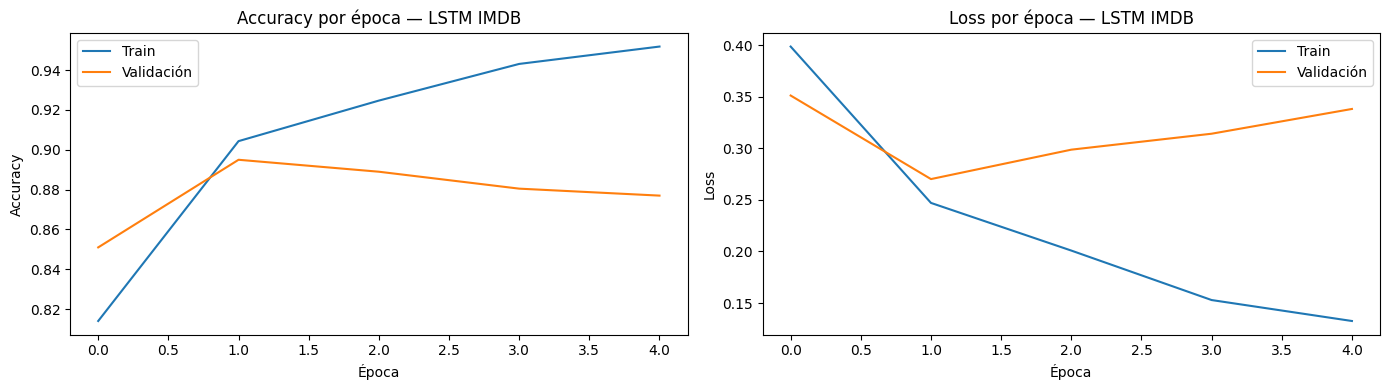


Epocas ejecutadas: 5 de 15 máximo
→ Early stopping activado


In [75]:
# Evaluación LSTM — IMDB
y_pred_lstm_imdb = (modelo_lstm.predict(X_test_seq_imdb) > 0.5).astype(int).flatten()
evaluar_modelo('IMDB', 'LSTM', y_test_imdb, y_pred_lstm_imdb, elapsed_lstm_imdb)

# Curvas de entrenamiento — LSTM IMDB
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(historia_imdb.history['accuracy'], label='Train')
axes[0].plot(historia_imdb.history['val_accuracy'], label='Validación')
axes[0].set_title('Accuracy por época — LSTM IMDB')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(historia_imdb.history['loss'], label='Train')
axes[1].plot(historia_imdb.history['val_loss'], label='Validación')
axes[1].set_title('Loss por época — LSTM IMDB')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

epocas_reales = len(historia_imdb.history['loss'])
print(f"\nEpocas ejecutadas: {epocas_reales} de 15 máximo")
print(f"→ Early stopping {'activado' if epocas_reales < 15 else 'no activado'}")

##  7.6 Resumen Fase 1

In [76]:
print("=" * 55)
print("RESUMEN FASE 1 — IMDB")
print("=" * 55)
print(f"\n{'Modelo':<20} {'Accuracy':>9} {'F1':>8} {'Tiempo':>8}")
print("-" * 48)

for clave in ['IMDB | NB + BoW', 'IMDB | NB + TF-IDF',
              'IMDB | LR + BoW', 'IMDB | LR + TF-IDF', 'IMDB | LSTM']:
    r = resultados[clave]
    nombre = clave.split(' | ')[1]
    print(f"{nombre:<20} {r['accuracy']:>9.4f} {r['f1']:>8.4f} {r['tiempo_s']:>7.2f}s")

# Mejor modelo de la fase
mejor = max(
    [k for k in resultados if k.startswith('IMDB')],
    key=lambda k: resultados[k]['f1']
)
print(f"\n→ Mejor modelo Fase 1: {mejor.split(' | ')[1]}")
print(f"  F1: {resultados[mejor]['f1']:.4f}")
print(f"\nEstos resultados son el baseline limpio.")
print(f"Las fases 2 y 3 se compararán contra estos números.")

RESUMEN FASE 1 — IMDB

Modelo                Accuracy       F1   Tiempo
------------------------------------------------
NB + BoW                0.8522   0.8527    0.04s
NB + TF-IDF             0.8696   0.8718    0.04s
LR + BoW                0.8782   0.8782   23.38s
LR + TF-IDF             0.8995   0.9003    0.85s
LSTM                    0.8899   0.8919  677.36s

→ Mejor modelo Fase 1: LR + TF-IDF
  F1: 0.9003

Estos resultados son el baseline limpio.
Las fases 2 y 3 se compararán contra estos números.


# 8. Modelos Clásicos y LSTM: Fase 2 (Yelp)


#### En esta sección se entrenan los mismos 5 modelos sobre el dataset Yelp ya limpiado. El objetivo es comparar si un dataset de dominio diferente (restaurantes vs películas) y con pipeline de limpieza más exigente produce resultados distintos al baseline.

## 8.1 Naive Bayes 

In [77]:
#  Naive Bayes con Bag of Words
nb_bow_yelp = entrenar_clasico(
    MultinomialNB(alpha=1.0),
    bow_yelp[0], bow_yelp[1],
    y_train_yelp, y_test_yelp,
    nombre_fase='Yelp',
    nombre_modelo='NB + BoW'
)


  Yelp | NB + BoW
  Accuracy : 0.8855
  Precision: 0.8629
  Recall   : 0.9165
  F1-Score : 0.8889
  Tiempo   : 0.02s


In [78]:
# Naive Bayes con TF-IDF
nb_tfidf_yelp = entrenar_clasico(
    MultinomialNB(alpha=1.0),
    tfidf_yelp[0], tfidf_yelp[1],
    y_train_yelp, y_test_yelp,
    nombre_fase='Yelp',
    nombre_modelo='NB + TF-IDF'
)


  Yelp | NB + TF-IDF
  Accuracy : 0.9011
  Precision: 0.8904
  Recall   : 0.9148
  F1-Score : 0.9025
  Tiempo   : 0.02s


## 8.2 Comparación inmediata NB Yelp vs IMDB


In [79]:
print("\nNB — Comparación IMDB vs Yelp:")
print(f"{'Modelo':<22} {'F1 IMDB':>9} {'F1 Yelp':>9} {'Diferencia':>12}")
print("-" * 55)
for modelo in ['NB + BoW', 'NB + TF-IDF']:
    f1_imdb = resultados[f'IMDB | {modelo}']['f1']
    f1_yelp = resultados[f'Yelp | {modelo}']['f1']
    diff = f1_yelp - f1_imdb
    signo = "↑" if diff > 0 else "↓"
    print(f"{modelo:<22} {f1_imdb:>9.4f} {f1_yelp:>9.4f} {diff:>+11.4f} {signo}")

print(f"\n→ Pregunta clave: ¿el pipeline de limpieza del Yelp fue suficiente")
print(f"  para alcanzar el rendimiento del IMDB limpio de origen?")


NB — Comparación IMDB vs Yelp:
Modelo                   F1 IMDB   F1 Yelp   Diferencia
-------------------------------------------------------
NB + BoW                  0.8527    0.8889     +0.0362 ↑
NB + TF-IDF               0.8718    0.9025     +0.0306 ↑

→ Pregunta clave: ¿el pipeline de limpieza del Yelp fue suficiente
  para alcanzar el rendimiento del IMDB limpio de origen?


## 8.3 Logistic Regression 


In [80]:
#con Bag of Words
lr_bow_yelp = entrenar_clasico(
    LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    bow_yelp[0], bow_yelp[1],
    y_train_yelp, y_test_yelp,
    nombre_fase='Yelp',
    nombre_modelo='LR + BoW'
)


  Yelp | LR + BoW
  Accuracy : 0.9337
  Precision: 0.9322
  Recall   : 0.9353
  F1-Score : 0.9338
  Tiempo   : 2.86s


In [81]:
#con TF-IDF
lr_tfidf_yelp = entrenar_clasico(
    LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    tfidf_yelp[0], tfidf_yelp[1],
    y_train_yelp, y_test_yelp,
    nombre_fase='Yelp',
    nombre_modelo='LR + TF-IDF'
)


  Yelp | LR + TF-IDF
  Accuracy : 0.9371
  Precision: 0.9393
  Recall   : 0.9346
  F1-Score : 0.9370
  Tiempo   : 0.35s


## 8.4 Comparación NB vs LR en Yelp


In [82]:
print("\nComparación NB vs LR — Yelp:")
print(f"{'Modelo':<20} {'Accuracy':>9} {'F1':>8} {'Tiempo':>8}")
print("-" * 48)
for clave in ['Yelp | NB + BoW', 'Yelp | NB + TF-IDF',
              'Yelp | LR + BoW', 'Yelp | LR + TF-IDF']:
    r = resultados[clave]
    nombre = clave.split(' | ')[1]
    print(f"{nombre:<20} {r['accuracy']:>9.4f} {r['f1']:>8.4f} {r['tiempo_s']:>7.2f}s")


Comparación NB vs LR — Yelp:
Modelo                Accuracy       F1   Tiempo
------------------------------------------------
NB + BoW                0.8855   0.8889    0.02s
NB + TF-IDF             0.9011   0.9025    0.02s
LR + BoW                0.9337   0.9338    2.86s
LR + TF-IDF             0.9371   0.9370    0.35s


## 8.5 LSTM — Yelp 

In [83]:
# Se instancia un nuevo modelo LSTM — misma arquitectura que Fase 1
# Los pesos NO se transfieren desde el modelo IMDB: cada fase
# entrena desde cero para que la comparación sea justa
modelo_lstm_yelp = build_lstm()

print("Entrenando LSTM sobre Yelp...")
print(f"Arquitectura idéntica a Fase 1 — pesos inicializados desde cero\n")

start = time.time()
historia_yelp = modelo_lstm_yelp.fit(
    X_train_seq_yelp, y_train_yelp,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                             restore_best_weights=True)],
    verbose=1
)
elapsed_lstm_yelp = time.time() - start
print(f"\n✓ Entrenamiento completado en {elapsed_lstm_yelp:.1f} segundos")

Entrenando LSTM sobre Yelp...
Arquitectura idéntica a Fase 1 — pesos inicializados desde cero

Epoch 1/15
171/171 ━━━━━━━━━━━━━━━━━━━━ 88s 487ms/step - accuracy: 0.8405 - loss: 0.3761 - val_accuracy: 0.9237 - val_loss: 0.2181
Epoch 2/15
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 482ms/step - accuracy: 0.9398 - loss: 0.1728 - val_accuracy: 0.8969 - val_loss: 0.3168
Epoch 3/15
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 482ms/step - accuracy: 0.9548 - loss: 0.1318 - val_accuracy: 0.9179 - val_loss: 0.2207
Epoch 4/15
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 478ms/step - accuracy: 0.9684 - loss: 0.0966 - val_accuracy: 0.9158 - val_loss: 0.2367

✓ Entrenamiento completado en 334.3 segundos


190/190 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step

  Yelp | LSTM
  Accuracy : 0.9157
  Precision: 0.9125
  Recall   : 0.9194
  F1-Score : 0.9160
  Tiempo   : 334.32s


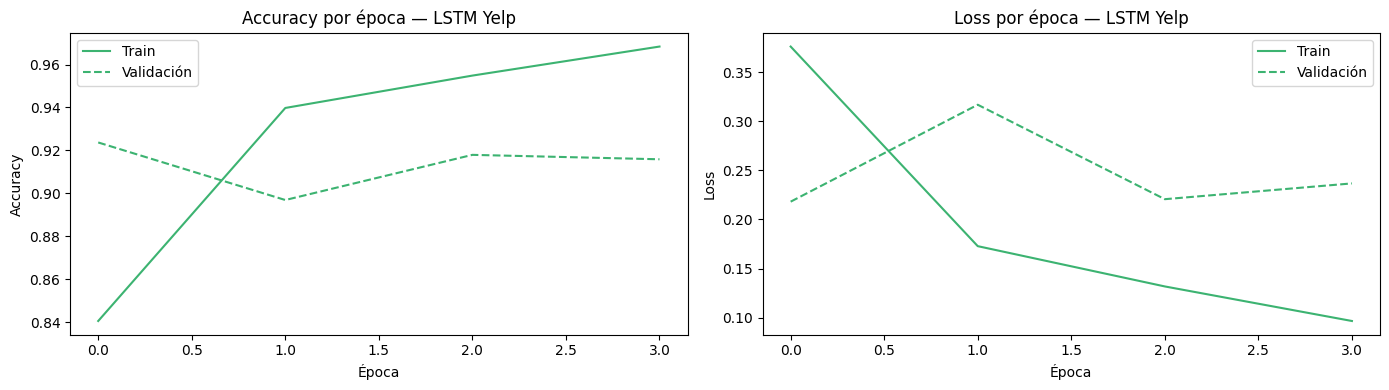

Épocas ejecutadas: 4 de 15 máximo
→ Early stopping activado


In [84]:
# Evaluación LSTM — Yelp
y_pred_lstm_yelp = (modelo_lstm_yelp.predict(
X_test_seq_yelp) > 0.5).astype(int).flatten()
evaluar_modelo('Yelp', 'LSTM', y_test_yelp, y_pred_lstm_yelp, elapsed_lstm_yelp)
# Curvas de entrenamiento — LSTM Yelp
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(historia_yelp.history['accuracy'], label='Train', color='mediumseagreen')
axes[0].plot(historia_yelp.history['val_accuracy'], label='Validación',
             color='mediumseagreen', linestyle='--')
axes[0].set_title('Accuracy por época — LSTM Yelp')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(historia_yelp.history['loss'], label='Train', color='mediumseagreen')
axes[1].plot(historia_yelp.history['val_loss'], label='Validación',
             color='mediumseagreen', linestyle='--')
axes[1].set_title('Loss por época — LSTM Yelp')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

epocas_yelp = len(historia_yelp.history['loss'])
print(f"Épocas ejecutadas: {epocas_yelp} de 15 máximo")
print(f"→ Early stopping {'activado' if epocas_yelp < 15 else 'no activado'}")

In [85]:
# Comparación LSTM — IMDB vs Yelp
print("\nLSTM — Comparación IMDB vs Yelp:")
f1_lstm_imdb = resultados['IMDB | LSTM']['f1']
f1_lstm_yelp = resultados['Yelp | LSTM']['f1']
diff = f1_lstm_yelp - f1_lstm_imdb
signo = "↑" if diff > 0 else "↓"

print(f"  F1 IMDB : {f1_lstm_imdb:.4f}")
print(f"  F1 Yelp : {f1_lstm_yelp:.4f}")
print(f"  Diferencia: {diff:+.4f} {signo}")
print(f"\n→ El LSTM, al aprender representaciones contextuales,")
print(f"  puede ser más o menos sensible al cambio de dominio")
print(f"  que los modelos clásicos basados en frecuencias")


LSTM — Comparación IMDB vs Yelp:
  F1 IMDB : 0.8919
  F1 Yelp : 0.9160
  Diferencia: +0.0241 ↑

→ El LSTM, al aprender representaciones contextuales,
  puede ser más o menos sensible al cambio de dominio
  que los modelos clásicos basados en frecuencias


## 8.6 Resumen Fase 2 

In [87]:
print("=" * 55)
print("RESUMEN FASE 2 — YELP")
print("=" * 55)
print(f"\n{'Modelo':<20} {'Accuracy':>9} {'F1':>8} {'Tiempo':>8}")
print("-" * 48)

for clave in ['Yelp | NB + BoW', 'Yelp | NB + TF-IDF',
              'Yelp | LR + BoW', 'Yelp | LR + TF-IDF', 'Yelp | LSTM']:
    r = resultados[clave]
    nombre = clave.split(' | ')[1]
    print(f"{nombre:<20} {r['accuracy']:>9.4f} {r['f1']:>8.4f} {r['tiempo_s']:>7.2f}s")

mejor_yelp = max(
    [k for k in resultados if k.startswith('Yelp')],
    key=lambda k: resultados[k]['f1']
)
print(f"\n→ Mejor modelo Fase 2: {mejor_yelp.split(' | ')[1]}")
print(f"  F1: {resultados[mejor_yelp]['f1']:.4f}")

# Comparación acumulada hasta ahora
print(f"\n{'─'*55}")
print(f"Comparación acumulada IMDB vs Yelp (F1):")
print(f"{'Modelo':<20} {'IMDB':>8} {'Yelp':>8} {'Δ':>8}")
print("-" * 48)
for modelo in ['NB + BoW', 'NB + TF-IDF', 'LR + BoW', 'LR + TF-IDF', 'LSTM']:
    f1_i = resultados[f'IMDB | {modelo}']['f1']
    f1_y = resultados[f'Yelp | {modelo}']['f1']
    diff = f1_y - f1_i
    print(f"{modelo:<20} {f1_i:>8.4f} {f1_y:>8.4f} {diff:>+8.4f}")

RESUMEN FASE 2 — YELP

Modelo                Accuracy       F1   Tiempo
------------------------------------------------
NB + BoW                0.8855   0.8889    0.02s
NB + TF-IDF             0.9011   0.9025    0.02s
LR + BoW                0.9337   0.9338    2.86s
LR + TF-IDF             0.9371   0.9370    0.35s
LSTM                    0.9157   0.9160  334.32s

→ Mejor modelo Fase 2: LR + TF-IDF
  F1: 0.9370

───────────────────────────────────────────────────────
Comparación acumulada IMDB vs Yelp (F1):
Modelo                   IMDB     Yelp        Δ
------------------------------------------------
NB + BoW               0.8527   0.8889  +0.0362
NB + TF-IDF            0.8718   0.9025  +0.0306
LR + BoW               0.8782   0.9338  +0.0556
LR + TF-IDF            0.9003   0.9370  +0.0366
LSTM                   0.8919   0.9160  +0.0241


# 9.  Modelos Clásicos y LSTM: Fase 3 (Combinado)

#### En esta sección se entrenan los mismos 5 modelos sobre el dataset combinado (IMDB + Yelp). El objetivo es evaluar si mezclar dominios y aumentar el volumen de datos mejora, mantiene o perjudica el rendimiento respecto a las fases anteriores.

#### Pregunta central de esta fase:
## ¿Más datos siempre es mejor, o la heterogeneidad de dominio introduce ruido que perjudica el aprendizaje?

## 9.1 Naive Bayes


In [88]:
# Naive Bayes con Bag of Words
nb_bow_comb = entrenar_clasico(
    MultinomialNB(alpha=1.0),
    bow_comb[0], bow_comb[1],
    y_train_comb, y_test_comb,
    nombre_fase='Combinado',
    nombre_modelo='NB + BoW'
)


  Combinado | NB + BoW
  Accuracy : 0.8671
  Precision: 0.8611
  Recall   : 0.8755
  F1-Score : 0.8682
  Tiempo   : 0.06s


In [89]:
# Naive Bayes con TF-IDF
nb_tfidf_comb = entrenar_clasico(
    MultinomialNB(alpha=1.0),
    tfidf_comb[0], tfidf_comb[1],
    y_train_comb, y_test_comb,
    nombre_fase='Combinado',
    nombre_modelo='NB + TF-IDF'
)


  Combinado | NB + TF-IDF
  Accuracy : 0.8772
  Precision: 0.8728
  Recall   : 0.8830
  F1-Score : 0.8779
  Tiempo   : 0.06s


## 9.2 Comparación NB — tres fases


In [90]:
print("NB — Evolución a través de las tres fases:")
print(f"{'Modelo':<22} {'IMDB':>8} {'Yelp':>8} {'Combinado':>10} {'Tendencia':>10}")
print("-" * 62)
for modelo in ['NB + BoW', 'NB + TF-IDF']:
    f1_i = resultados[f'IMDB | {modelo}']['f1']
    f1_y = resultados[f'Yelp | {modelo}']['f1']
    f1_c = resultados[f'Combinado | {modelo}']['f1']
    if f1_c > f1_i and f1_c > f1_y:
        tendencia = '↑ mejor'
    elif f1_c < f1_i and f1_c < f1_y:
        tendencia = '↓ peor'
    else:
        tendencia = '→ mixto'
    print(f"{modelo:<22} {f1_i:>8.4f} {f1_y:>8.4f} {f1_c:>10.4f} {tendencia:>10}")

print(f"\n→ Si el combinado mejora: el volumen adicional compensa")
print(f"  la heterogeneidad de dominio")
print(f"→ Si el combinado empeora: mezclar dominios introduce")
print(f"  señal contradictoria que confunde al modelo")

NB — Evolución a través de las tres fases:
Modelo                     IMDB     Yelp  Combinado  Tendencia
--------------------------------------------------------------
NB + BoW                 0.8527   0.8889     0.8682    → mixto
NB + TF-IDF              0.8718   0.9025     0.8779    → mixto

→ Si el combinado mejora: el volumen adicional compensa
  la heterogeneidad de dominio
→ Si el combinado empeora: mezclar dominios introduce
  señal contradictoria que confunde al modelo


## 9.3 Logistic Regression

In [91]:
# Logistic Regression con Bag of Words
lr_bow_comb = entrenar_clasico(
    LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    bow_comb[0], bow_comb[1],
    y_train_comb, y_test_comb,
    nombre_fase='Combinado',
    nombre_modelo='LR + BoW'
)


  Combinado | LR + BoW
  Accuracy : 0.8900
  Precision: 0.8877
  Recall   : 0.8929
  F1-Score : 0.8903
  Tiempo   : 31.57s


In [92]:
# Logistic Regression con TF-IDF
lr_tfidf_comb = entrenar_clasico(
    LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    tfidf_comb[0], tfidf_comb[1],
    y_train_comb, y_test_comb,
    nombre_fase='Combinado',
    nombre_modelo='LR + TF-IDF'
)


  Combinado | LR + TF-IDF
  Accuracy : 0.9088
  Precision: 0.9063
  Recall   : 0.9118
  F1-Score : 0.9090
  Tiempo   : 1.69s


## 9.4 Comparación LR — tres fases


In [93]:
print("LR — Evolución a través de las tres fases:")
print(f"{'Modelo':<22} {'IMDB':>8} {'Yelp':>8} {'Combinado':>10} {'Tendencia':>10}")
print("-" * 62)
for modelo in ['LR + BoW', 'LR + TF-IDF']:
    f1_i = resultados[f'IMDB | {modelo}']['f1']
    f1_y = resultados[f'Yelp | {modelo}']['f1']
    f1_c = resultados[f'Combinado | {modelo}']['f1']
    if f1_c > f1_i and f1_c > f1_y:
        tendencia = '↑ mejor'
    elif f1_c < f1_i and f1_c < f1_y:
        tendencia = '↓ peor'
    else:
        tendencia = '→ mixto'
    print(f"{modelo:<22} {f1_i:>8.4f} {f1_y:>8.4f} {f1_c:>10.4f} {tendencia:>10}")

print(f"\n→ LR con TF-IDF es el experimento más interesante aquí:")
print(f"  TF-IDF normaliza frecuencias a nivel de corpus, por lo que")
print(f"  al combinar dominios el corpus de referencia cambia y los")
print(f"  pesos de las palabras se redistribuyen globalmente")

LR — Evolución a través de las tres fases:
Modelo                     IMDB     Yelp  Combinado  Tendencia
--------------------------------------------------------------
LR + BoW                 0.8782   0.9338     0.8903    → mixto
LR + TF-IDF              0.9003   0.9370     0.9090    → mixto

→ LR con TF-IDF es el experimento más interesante aquí:
  TF-IDF normaliza frecuencias a nivel de corpus, por lo que
  al combinar dominios el corpus de referencia cambia y los
  pesos de las palabras se redistribuyen globalmente


##  9.5 LSTM — Combinado 


In [94]:
# Nueva instancia del modelo — misma arquitectura, pesos desde cero
modelo_lstm_comb = build_lstm()

print("Entrenando LSTM sobre dataset combinado...")
print(f"Dataset: {len(X_train_seq_comb)} ejemplos de entrenamiento")
print(f"(vs {len(X_train_seq_imdb)} en IMDB y {len(X_train_seq_yelp)} en Yelp)\n")

start = time.time()
historia_comb = modelo_lstm_comb.fit(
    X_train_seq_comb, y_train_comb,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3,
                             restore_best_weights=True)],
    verbose=1
)
elapsed_lstm_comb = time.time() - start
print(f"\n✓ Entrenamiento completado en {elapsed_lstm_comb:.1f} segundos")

Entrenando LSTM sobre dataset combinado...
Dataset: 64235 ejemplos de entrenamiento
(vs 40000 en IMDB y 24235 en Yelp)

Epoch 1/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 224s 488ms/step - accuracy: 0.8516 - loss: 0.3427 - val_accuracy: 0.8823 - val_loss: 0.2881
Epoch 2/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 219s 484ms/step - accuracy: 0.9128 - loss: 0.2295 - val_accuracy: 0.8719 - val_loss: 0.3133
Epoch 3/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 217s 480ms/step - accuracy: 0.9270 - loss: 0.1923 - val_accuracy: 0.8937 - val_loss: 0.2725
Epoch 4/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 217s 479ms/step - accuracy: 0.9396 - loss: 0.1603 - val_accuracy: 0.8923 - val_loss: 0.2897
Epoch 5/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 217s 480ms/step - accuracy: 0.9378 - loss: 0.1663 - val_accuracy: 0.8884 - val_loss: 0.3049
Epoch 6/15
452/452 ━━━━━━━━━━━━━━━━━━━━ 217s 480ms/step - accuracy: 0.9573 - loss: 0.1184 - val_accuracy: 0.8871 - val_loss: 0.3400

✓ Entrenamiento completado en 1310.5 segundos


502/502 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step

  Combinado | LSTM
  Accuracy : 0.9003
  Precision: 0.8965
  Recall   : 0.9051
  F1-Score : 0.9008
  Tiempo   : 1310.48s


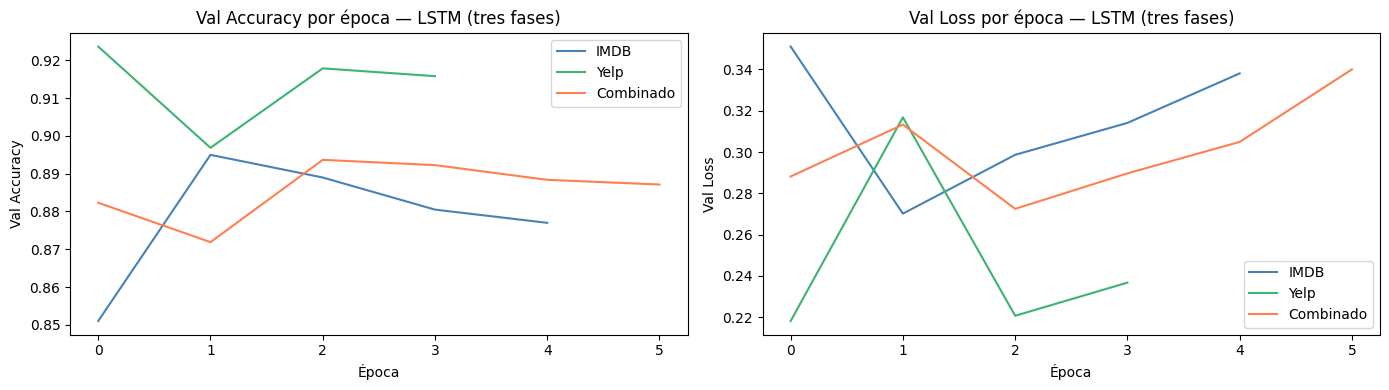

Épocas ejecutadas: 6 de 15 máximo
→ Early stopping activado

→ La gráfica superpuesta permite ver si el combinado
  converge más rápido gracias al mayor volumen de datos


In [95]:
# Evaluación LSTM — Combinado
y_pred_lstm_comb = (modelo_lstm_comb.predict(
    X_test_seq_comb) > 0.5).astype(int).flatten()
evaluar_modelo('Combinado', 'LSTM', y_test_comb, y_pred_lstm_comb, elapsed_lstm_comb)
# Curvas de entrenamiento — LSTM Combinado
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Superponer las tres curvas para comparación visual
for historia, label, color in zip(
    [historia_imdb, historia_yelp, historia_comb],
    ['IMDB', 'Yelp', 'Combinado'],
    ['steelblue', 'mediumseagreen', 'coral']
):
    axes[0].plot(historia.history['val_accuracy'],
                 label=label, color=color)
    axes[1].plot(historia.history['val_loss'],
                 label=label, color=color)

axes[0].set_title('Val Accuracy por época — LSTM (tres fases)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Val Accuracy')
axes[0].legend()

axes[1].set_title('Val Loss por época — LSTM (tres fases)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Val Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

epocas_comb = len(historia_comb.history['loss'])
print(f"Épocas ejecutadas: {epocas_comb} de 15 máximo")
print(f"→ Early stopping {'activado' if epocas_comb < 15 else 'no activado'}")
print(f"\n→ La gráfica superpuesta permite ver si el combinado")
print(f"  converge más rápido gracias al mayor volumen de datos")

## 9.6 Resumen Fase 3 

In [97]:
print("=" * 55)
print("RESUMEN FASE 3 — COMBINADO")
print("=" * 55)
print(f"\n{'Modelo':<20} {'Accuracy':>9} {'F1':>8} {'Tiempo':>8}")
print("-" * 48)

for clave in ['Combinado | NB + BoW', 'Combinado | NB + TF-IDF',
              'Combinado | LR + BoW', 'Combinado | LR + TF-IDF',
              'Combinado | LSTM']:
    r = resultados[clave]
    nombre = clave.split(' | ')[1]
    print(f"{nombre:<20} {r['accuracy']:>9.4f} {r['f1']:>8.4f} {r['tiempo_s']:>7.2f}s")

mejor_comb = max(
    [k for k in resultados if k.startswith('Combinado')],
    key=lambda k: resultados[k]['f1']
)
print(f"\n→ Mejor modelo Fase 3: {mejor_comb.split(' | ')[1]}")
print(f"  F1: {resultados[mejor_comb]['f1']:.4f}")

# Tabla comparativa acumulada — las tres fases
print(f"\n{'─'*62}")
print(f"Comparación acumulada — F1 por modelo y fase:")
print(f"{'Modelo':<20} {'IMDB':>8} {'Yelp':>8} {'Combinado':>10} {'Mejor fase':>12}")
print("-" * 62)

for modelo in ['NB + BoW', 'NB + TF-IDF', 'LR + BoW', 'LR + TF-IDF', 'LSTM']:
    f1_i = resultados[f'IMDB | {modelo}']['f1']
    f1_y = resultados[f'Yelp | {modelo}']['f1']
    f1_c = resultados[f'Combinado | {modelo}']['f1']
    mejor = max([('IMDB', f1_i), ('Yelp', f1_y), ('Combinado', f1_c)],
                key=lambda x: x[1])
    print(f"{modelo:<20} {f1_i:>8.4f} {f1_y:>8.4f} {f1_c:>10.4f} {mejor[0]:>12}")

RESUMEN FASE 3 — COMBINADO

Modelo                Accuracy       F1   Tiempo
------------------------------------------------
NB + BoW                0.8671   0.8682    0.06s
NB + TF-IDF             0.8772   0.8779    0.06s
LR + BoW                0.8900   0.8903   31.57s
LR + TF-IDF             0.9088   0.9090    1.69s
LSTM                    0.9003   0.9008 1310.48s

→ Mejor modelo Fase 3: LR + TF-IDF
  F1: 0.9090

──────────────────────────────────────────────────────────────
Comparación acumulada — F1 por modelo y fase:
Modelo                   IMDB     Yelp  Combinado   Mejor fase
--------------------------------------------------------------
NB + BoW               0.8527   0.8889     0.8682         Yelp
NB + TF-IDF            0.8718   0.9025     0.8779         Yelp
LR + BoW               0.8782   0.9338     0.8903         Yelp
LR + TF-IDF            0.9003   0.9370     0.9090         Yelp
LSTM                   0.8919   0.9160     0.9008         Yelp


# 10. Comparaciones

In [98]:
# Comparación LSTM — tres fases
print("\nLSTM — Evolución a través de las tres fases:")
f1_i = resultados['IMDB | LSTM']['f1']
f1_y = resultados['Yelp | LSTM']['f1']
f1_c = resultados['Combinado | LSTM']['f1']

print(f"  F1 IMDB      : {f1_i:.4f}")
print(f"  F1 Yelp      : {f1_y:.4f}")
print(f"  F1 Combinado : {f1_c:.4f}")

if f1_c > max(f1_i, f1_y):
    conclusion = "El LSTM se beneficia del mayor volumen — más datos mejoran los embeddings"
elif f1_c < min(f1_i, f1_y):
    conclusion = "La heterogeneidad de dominio perjudica al LSTM más que a los modelos clásicos"
else:
    conclusion = "El LSTM queda entre ambas fases — el dominio mixto tiene efecto moderado"

print(f"\n→ {conclusion}")


LSTM — Evolución a través de las tres fases:
  F1 IMDB      : 0.8919
  F1 Yelp      : 0.9160
  F1 Combinado : 0.9008

→ El LSTM queda entre ambas fases — el dominio mixto tiene efecto moderado


In [100]:
# Comparar vocabularios para entender el impacto de combinar dominios
# Se usan los tokenizadores de la Ruta B (LSTM)

vocab_imdb = set(list(tok_imdb.word_index.keys())[:MAX_FEATURES])
vocab_yelp = set(list(tok_yelp.word_index.keys())[:MAX_FEATURES])
vocab_comb = set(list(tok_comb.word_index.keys())[:MAX_FEATURES])

solo_imdb    = vocab_imdb - vocab_yelp
solo_yelp    = vocab_yelp - vocab_imdb
compartido   = vocab_imdb & vocab_yelp
nuevo_comb   = vocab_comb - vocab_imdb - vocab_yelp

print("=" * 55)
print("ANÁLISIS DE VOCABULARIO ENTRE DOMINIOS")
print("=" * 55)
print(f"Vocabulario IMDB (top {MAX_FEATURES}): {len(vocab_imdb):>7} palabras")
print(f"Vocabulario Yelp (top {MAX_FEATURES}): {len(vocab_yelp):>7} palabras")
print(f"Vocabulario Combinado:          {len(vocab_comb):>7} palabras")
print(f"\nPalabras exclusivas de IMDB:    {len(solo_imdb):>7}")
print(f"Palabras exclusivas de Yelp:    {len(solo_yelp):>7}")
print(f"Palabras compartidas:           {len(compartido):>7}")

print(f"\nEjemplos de palabras exclusivas de IMDB (dominio cine):")
print(f"  {list(solo_imdb)[:15]}")
print(f"\nEjemplos de palabras exclusivas de Yelp (dominio restaurantes):")
print(f"  {list(solo_yelp)[:15]}")
print(f"\n→ Este análisis explica por qué combinar dominios puede")
print(f"  diluir señales específicas de cada dominio en el vocabulario")

ANÁLISIS DE VOCABULARIO ENTRE DOMINIOS
Vocabulario IMDB (top 10000):   10000 palabras
Vocabulario Yelp (top 10000):   10000 palabras
Vocabulario Combinado:            10000 palabras

Palabras exclusivas de IMDB:       4135
Palabras exclusivas de Yelp:       4135
Palabras compartidas:              5865

Ejemplos de palabras exclusivas de IMDB (dominio cine):
  ['emptiness', 'sexual', 'steiner', 'cecil', 'commandment', 'genie', 'polly', 'binoche', 'ingrid', 'wheeler', 'interval', 'smarter', 'slang', 'mystical', 'compromised']

Ejemplos de palabras exclusivas de Yelp (dominio restaurantes):
  ['consumer', 'brag', 'plump', 'initiative', 'pleasantry', 'germantown', 'ornament', 'watercress', 'isnt', 'parmigiana', 'touff', 'ahhh', 'restroom', 'benedict', 'renamed']

→ Este análisis explica por qué combinar dominios puede
  diluir señales específicas de cada dominio en el vocabulario


## 10.1 Análisis de errores — Dataset Combinado 


In [101]:

# El análisis de errores se realiza sobre el dataset combinado
# porque es el escenario más rico: el modelo ha aprendido de dos
# dominios distintos y los errores pueden revelar si el conflicto
# de dominio (cine vs restaurantes) afecta la clasificación

modelos_clasicos_comb = ['Combinado | NB + BoW', 'Combinado | NB + TF-IDF',
                          'Combinado | LR + BoW', 'Combinado | LR + TF-IDF']
mejor_clasico_comb = max(modelos_clasicos_comb, key=lambda k: resultados[k]['f1'])
print(f"Mejor modelo clásico en Combinado: {mejor_clasico_comb.split(' | ')[1]}")

# Reconstruir predicciones
if 'LR + TF-IDF' in mejor_clasico_comb:
    y_pred_mejor = lr_tfidf_comb.predict(tfidf_comb[1])
elif 'LR + BoW' in mejor_clasico_comb:
    y_pred_mejor = lr_bow_comb.predict(bow_comb[1])
elif 'NB + TF-IDF' in mejor_clasico_comb:
    y_pred_mejor = nb_tfidf_comb.predict(tfidf_comb[1])
else:
    y_pred_mejor = nb_bow_comb.predict(bow_comb[1])

# Construir dataframe de errores — conservando la columna source
X_test_comb_reset = X_test_comb.reset_index(drop=True)
y_test_comb_reset = y_test_comb.reset_index(drop=True)

# Recuperar source del test set
source_test = df_combined.loc[X_test_comb.index, 'source'].reset_index(drop=True)

errores = pd.DataFrame({
    'texto'     : X_test_comb_reset,
    'source'    : source_test,
    'real'      : y_test_comb_reset,
    'prediccion': y_pred_mejor
})
errores = errores[errores['real'] != errores['prediccion']]

print(f"\nTotal de errores: {len(errores):,} de {len(y_test_comb):,} reseñas de test")
print(f"Tasa de error   : {len(errores)/len(y_test_comb)*100:.1f}%")

# Distribución de errores por fuente — esto es lo más valioso
print(f"\nDistribución de errores por dominio:")
errores_por_source = errores['source'].value_counts()
total_por_source   = pd.Series(source_test).value_counts()
for src in ['imdb', 'yelp']:
    n_err  = errores_por_source.get(src, 0)
    n_tot  = total_por_source.get(src, 0)
    tasa   = n_err / n_tot * 100 if n_tot > 0 else 0
    print(f"  {src.upper():<6}: {n_err:>4} errores de {n_tot:>5} reseñas ({tasa:.1f}%)")

print(f"\n→ Si la tasa de error es mayor en un dominio, sugiere que")
print(f"  el vocabulario de ese dominio quedó subrepresentado")
print(f"  en el corpus combinado tras la vectorización conjunta")

# Ejemplos de errores — separados por dominio
for dominio in ['imdb', 'yelp']:
    print(f"\n{'─'*55}")
    print(f"Ejemplos de errores — {dominio.upper()}")
    print(f"{'─'*55}")

    subset = errores[errores['source'] == dominio]

    fp = subset[subset['prediccion'] == 1].head(2)
    print(f"\nFalsos positivos (predijo positivo siendo negativo):")
    for _, row in fp.iterrows():
        print(f"\n  Texto: {row['texto'][:200]}...")

    fn = subset[subset['prediccion'] == 0].head(2)
    print(f"\nFalsos negativos (predijo negativo siendo positivo):")
    for _, row in fn.iterrows():
        print(f"\n  Texto: {row['texto'][:200]}...")

print(f"\n→ Patrones esperados en errores de dominio mixto:")
print(f"  - Vocabulario específico de cine malinterpretado en contexto")
print(f"    de restaurantes y viceversa")
print(f"  - Sarcasmo e ironía que los modelos basados en frecuencias")
print(f"    no capturan independientemente del dominio")
print(f"  - Reseñas con sentimientos mixtos donde el rating no refleja")
print(f"    claramente el texto")

Mejor modelo clásico en Combinado: LR + TF-IDF

Total de errores: 1,465 de 16,059 reseñas de test
Tasa de error   : 9.1%

Distribución de errores por dominio:
  IMDB  : 1055 errores de 10098 reseñas (10.4%)
  YELP  :  410 errores de  5961 reseñas (6.9%)

→ Si la tasa de error es mayor en un dominio, sugiere que
  el vocabulario de ese dominio quedó subrepresentado
  en el corpus combinado tras la vectorización conjunta

───────────────────────────────────────────────────────
Ejemplos de errores — IMDB
───────────────────────────────────────────────────────

Falsos positivos (predijo positivo siendo negativo):

  Texto: despite the excellent cast this unremarkable film especially from the aviation perspective may somewhat better than the egregious von richthofen and brown but not much blue max remains the best small ...

  Texto: richard farnsworth one favorite actor usually give solid performance such the straight story and the grey fox also doe fairly well here but the rest the film s

## 10.2 Tabla comparativa de los 15 experimentos

In [102]:
# Construir DataFrame de resultados
filas = []
for clave, metricas in resultados.items():
    fase, modelo = clave.split(' | ')
    filas.append({
        'Fase'     : fase,
        'Modelo'   : modelo,
        'Accuracy' : metricas['accuracy'],
        'Precision': metricas['precision'],
        'Recall'   : metricas['recall'],
        'F1'       : metricas['f1'],
        'Tiempo(s)': metricas['tiempo_s']
    })

df_resultados = pd.DataFrame(filas)
df_resultados = df_resultados.sort_values(
    ['Fase', 'F1'], ascending=[True, False]
).reset_index(drop=True)

print("=" * 70)
print("TABLA COMPARATIVA — 15 EXPERIMENTOS")
print("=" * 70)
print(df_resultados.to_string(index=False, float_format='{:.4f}'.format))

# Mejor experimento global
mejor_global = df_resultados.loc[df_resultados['F1'].idxmax()]
print(f"\n→ Mejor experimento global:")
print(f"  Fase: {mejor_global['Fase']} | Modelo: {mejor_global['Modelo']}")
print(f"  F1: {mejor_global['F1']:.4f} | Accuracy: {mejor_global['Accuracy']:.4f}")

TABLA COMPARATIVA — 15 EXPERIMENTOS
     Fase      Modelo  Accuracy  Precision  Recall     F1  Tiempo(s)
Combinado LR + TF-IDF    0.9088     0.9063  0.9118 0.9090     1.6900
Combinado        LSTM    0.9003     0.8965  0.9051 0.9008  1310.4800
Combinado    LR + BoW    0.8900     0.8877  0.8929 0.8903    31.5700
Combinado NB + TF-IDF    0.8772     0.8728  0.8830 0.8779     0.0600
Combinado    NB + BoW    0.8671     0.8611  0.8755 0.8682     0.0600
     IMDB LR + TF-IDF    0.8995     0.8930  0.9078 0.9003     0.8500
     IMDB        LSTM    0.8899     0.8760  0.9084 0.8919   677.3600
     IMDB    LR + BoW    0.8782     0.8785  0.8778 0.8782    23.3800
     IMDB NB + TF-IDF    0.8696     0.8572  0.8870 0.8718     0.0400
     IMDB    NB + BoW    0.8522     0.8497  0.8558 0.8527     0.0400
     Yelp LR + TF-IDF    0.9371     0.9393  0.9346 0.9370     0.3500
     Yelp    LR + BoW    0.9337     0.9322  0.9353 0.9338     2.8600
     Yelp        LSTM    0.9157     0.9125  0.9194 0.9160   334.320

## 10.3 Visualización comparativa de F1 

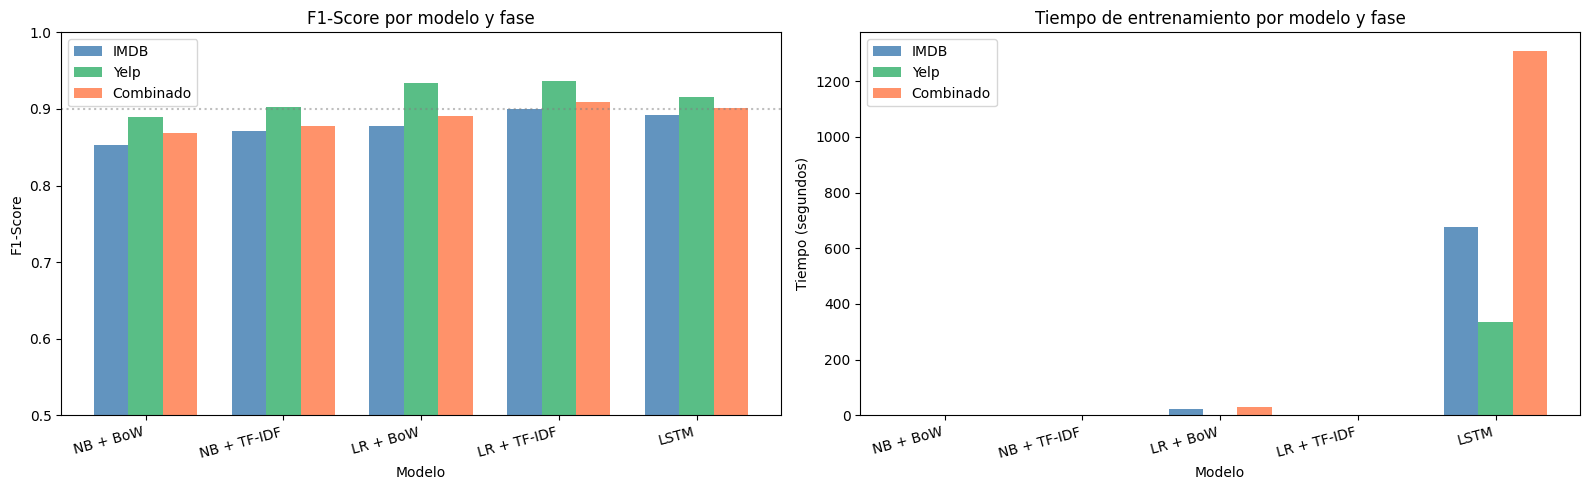

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1 — F1 por modelo y fase
modelos   = ['NB + BoW', 'NB + TF-IDF', 'LR + BoW', 'LR + TF-IDF', 'LSTM']
fases     = ['IMDB', 'Yelp', 'Combinado']
colores   = ['steelblue', 'mediumseagreen', 'coral']
x         = range(len(modelos))
width     = 0.25

for i, (fase, color) in enumerate(zip(fases, colores)):
    valores = [resultados[f'{fase} | {m}']['f1'] for m in modelos]
    offset  = (i - 1) * width
    bars    = axes[0].bar([xi + offset for xi in x], valores,
                          width, label=fase, color=color, alpha=0.85)

axes[0].set_title('F1-Score por modelo y fase')
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('F1-Score')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(modelos, rotation=15, ha='right')
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)
axes[0].axhline(0.9, color='gray', linestyle=':', alpha=0.5, label='Ref 0.90')

# Gráfico 2 — Tiempo de entrenamiento
for i, (fase, color) in enumerate(zip(fases, colores)):
    tiempos = [resultados[f'{fase} | {m}']['tiempo_s'] for m in modelos]
    offset  = (i - 1) * width
    axes[1].bar([xi + offset for xi in x], tiempos,
                width, label=fase, color=color, alpha=0.85)

axes[1].set_title('Tiempo de entrenamiento por modelo y fase')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Tiempo (segundos)')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(modelos, rotation=15, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10.4 Heatmap de F1 — visión global 

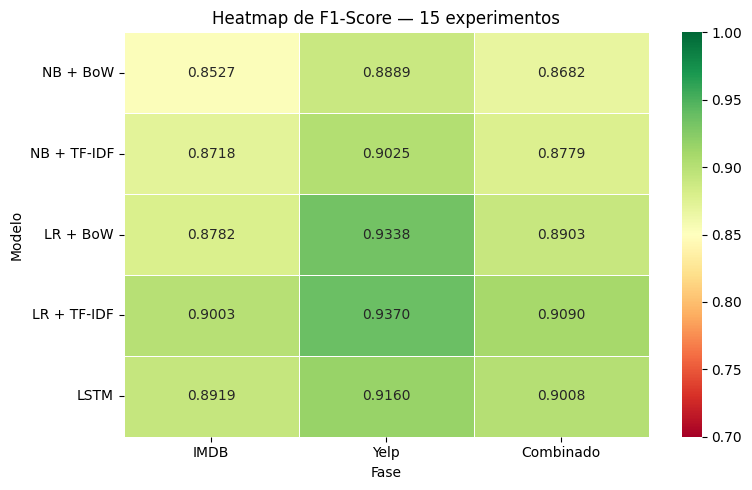

→ Verde = mejor rendimiento | Rojo = menor rendimiento
  Lectura por fila: impacto del dominio sobre un mismo modelo
  Lectura por columna: qué modelo funciona mejor en cada fase


In [104]:
# Pivot para heatmap
pivot_f1 = df_resultados.pivot(index='Modelo', columns='Fase', values='F1')
pivot_f1 = pivot_f1.reindex(columns=['IMDB', 'Yelp', 'Combinado'])
pivot_f1 = pivot_f1.reindex(modelos)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot_f1,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',
    vmin=0.7, vmax=1.0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Heatmap de F1-Score — 15 experimentos')
ax.set_xlabel('Fase')
ax.set_ylabel('Modelo')
plt.tight_layout()
plt.show()

print("→ Verde = mejor rendimiento | Rojo = menor rendimiento")
print("  Lectura por fila: impacto del dominio sobre un mismo modelo")
print("  Lectura por columna: qué modelo funciona mejor en cada fase")

##  10.5 Matrices de confusión 

In [106]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Recolectar predicciones de todos los modelos
# Se almacenan durante el entrenamiento para usarlas aquí
predicciones = {
    'IMDB | NB + BoW'      : nb_bow_imdb.predict(bow_imdb[1]),
    'IMDB | NB + TF-IDF'   : nb_tfidf_imdb.predict(tfidf_imdb[1]),
    'IMDB | LR + BoW'      : lr_bow_imdb.predict(bow_imdb[1]),
    'IMDB | LR + TF-IDF'   : lr_tfidf_imdb.predict(tfidf_imdb[1]),
    'IMDB | LSTM'          : y_pred_lstm_imdb,
    'Yelp | NB + BoW'      : nb_bow_yelp.predict(bow_yelp[1]),
    'Yelp | NB + TF-IDF'   : nb_tfidf_yelp.predict(tfidf_yelp[1]),
    'Yelp | LR + BoW'      : lr_bow_yelp.predict(bow_yelp[1]),
    'Yelp | LR + TF-IDF'   : lr_tfidf_yelp.predict(tfidf_yelp[1]),
    'Yelp | LSTM'          : y_pred_lstm_yelp,
    'Combinado | NB + BoW' : nb_bow_comb.predict(bow_comb[1]),
    'Combinado | NB + TF-IDF': nb_tfidf_comb.predict(tfidf_comb[1]),
    'Combinado | LR + BoW' : lr_bow_comb.predict(bow_comb[1]),
    'Combinado | LR + TF-IDF': lr_tfidf_comb.predict(tfidf_comb[1]),
    'Combinado | LSTM'     : y_pred_lstm_comb,
}

y_tests = {
    'IMDB'     : y_test_imdb,
    'Yelp'     : y_test_yelp,
    'Combinado': y_test_comb,
}

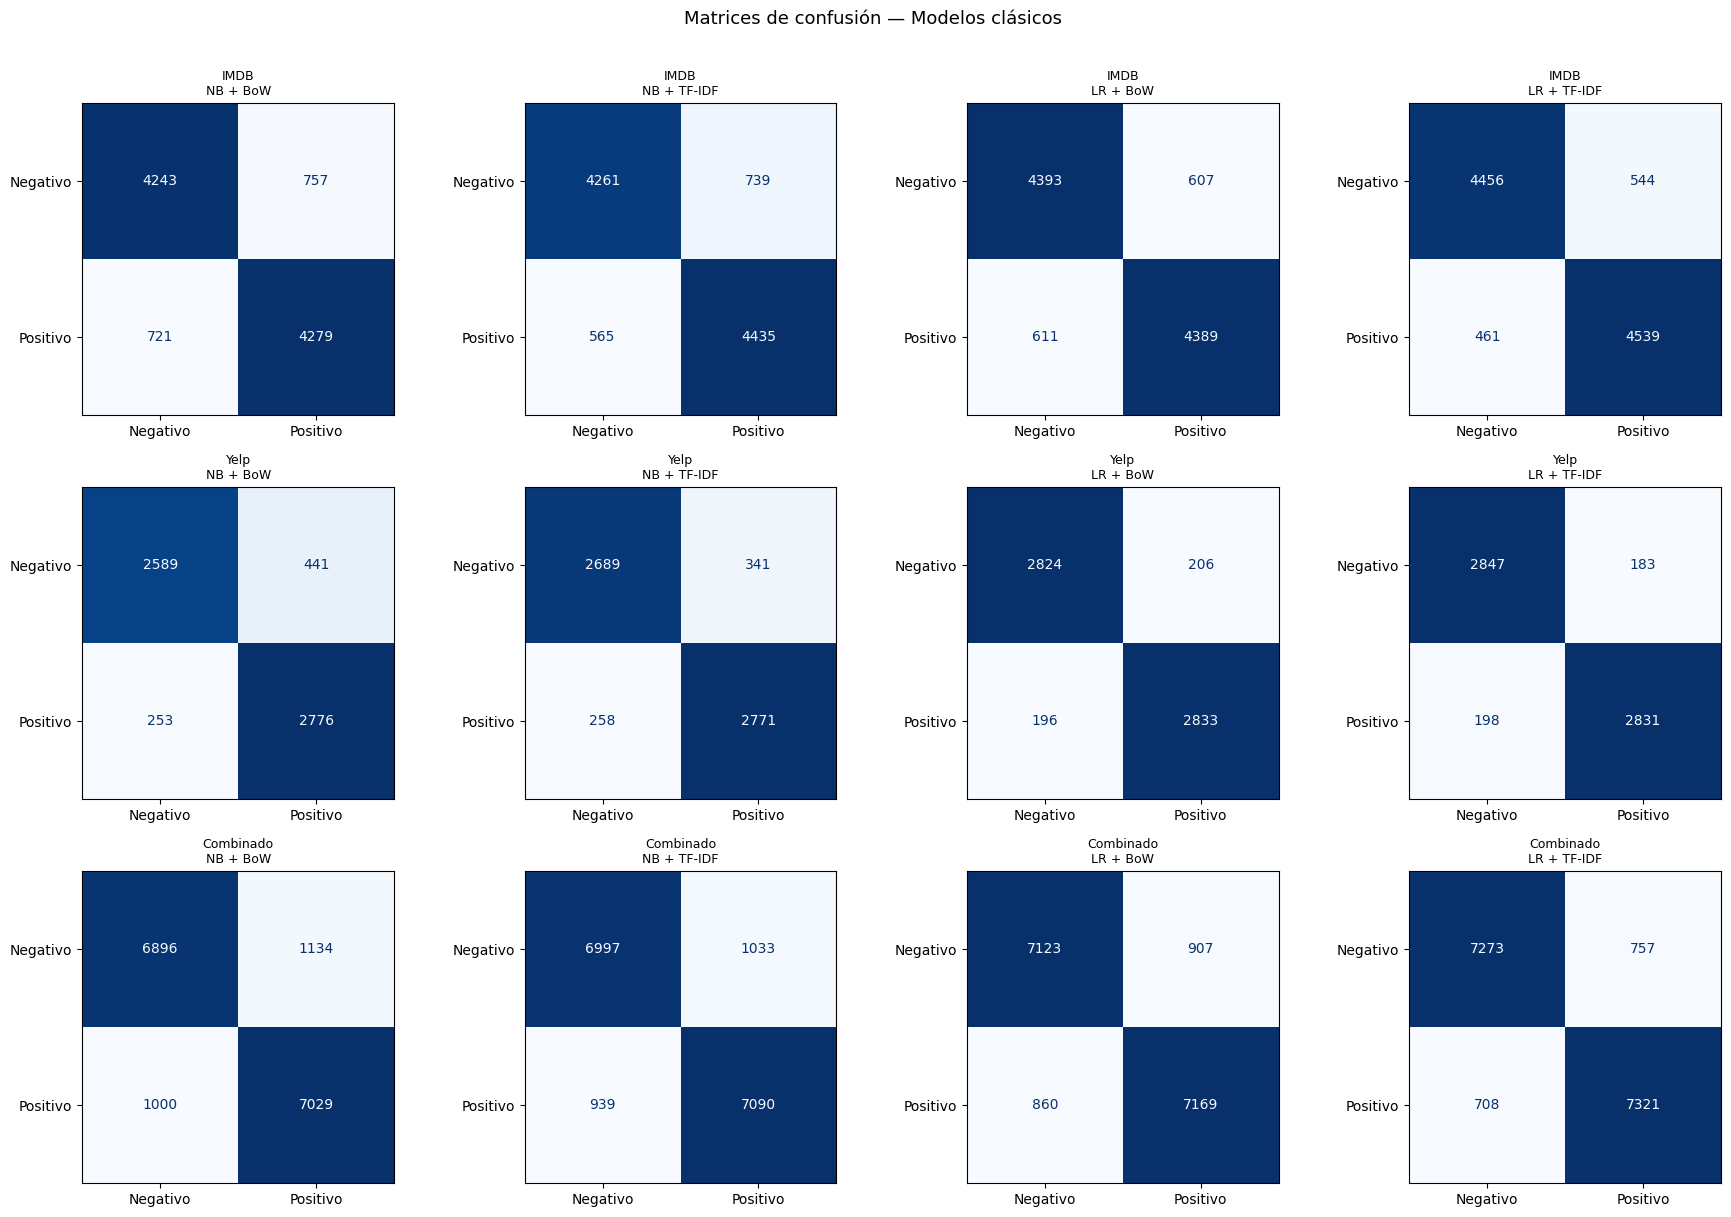

In [107]:
# Matrices de confusión — modelos clásicos por fase
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for row, fase in enumerate(['IMDB', 'Yelp', 'Combinado']):
    for col, modelo in enumerate(['NB + BoW', 'NB + TF-IDF',
                                   'LR + BoW', 'LR + TF-IDF']):
        clave  = f'{fase} | {modelo}'
        y_true = y_tests[fase]
        y_pred = predicciones[clave]
        cm     = confusion_matrix(y_true, y_pred)

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Negativo', 'Positivo']
        )
        disp.plot(ax=axes[row][col], colorbar=False, cmap='Blues')
        axes[row][col].set_title(f'{fase}\n{modelo}', fontsize=9)
        axes[row][col].set_xlabel('')
        axes[row][col].set_ylabel('')

plt.suptitle('Matrices de confusión — Modelos clásicos', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

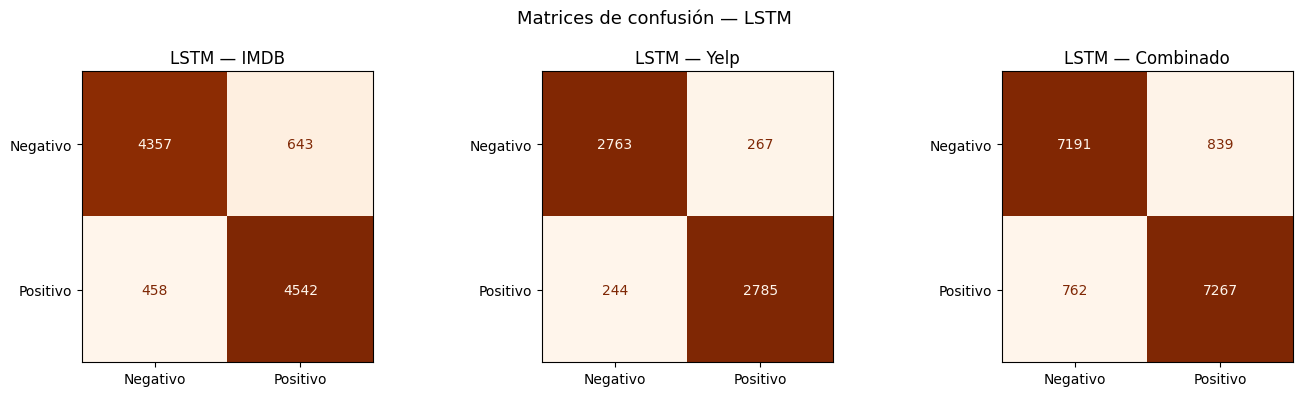

In [108]:
# Matrices de confusión — LSTM por fase
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for col, fase in enumerate(['IMDB', 'Yelp', 'Combinado']):
    clave  = f'{fase} | LSTM'
    y_true = y_tests[fase]
    y_pred = predicciones[clave]
    cm     = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Negativo', 'Positivo']
    )
    disp.plot(ax=axes[col], colorbar=False, cmap='Oranges')
    axes[col].set_title(f'LSTM — {fase}')
    axes[col].set_xlabel('')
    axes[col].set_ylabel('')

plt.suptitle('Matrices de confusión — LSTM', fontsize=13)
plt.tight_layout()
plt.show()

##  10.6 Análisis de precision vs recall 

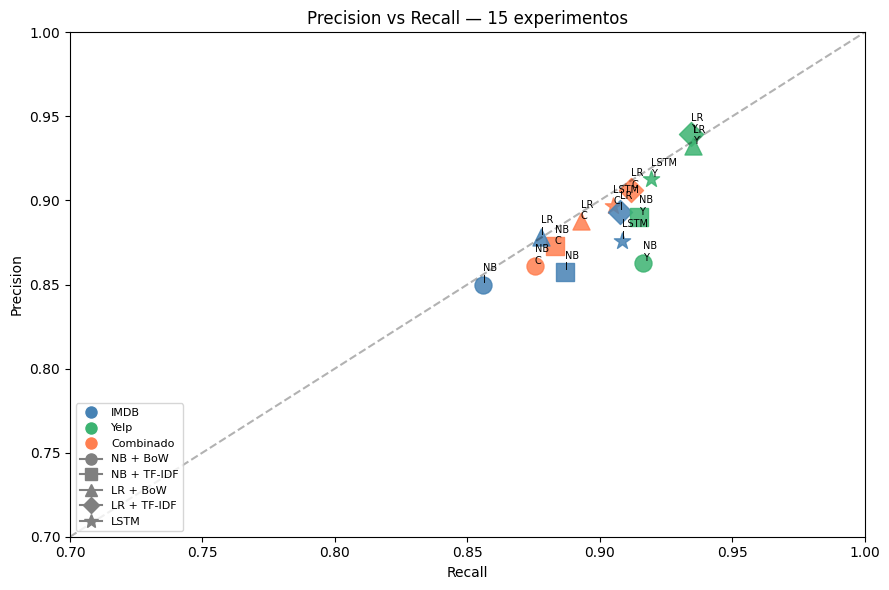

In [109]:
# Scatter plot precision vs recall coloreado por fase
fig, ax = plt.subplots(figsize=(9, 6))

markers = {'NB + BoW': 'o', 'NB + TF-IDF': 's',
           'LR + BoW': '^', 'LR + TF-IDF': 'D', 'LSTM': '*'}
colores_fase = {'IMDB': 'steelblue', 'Yelp': 'mediumseagreen',
                'Combinado': 'coral'}

for _, row in df_resultados.iterrows():
    ax.scatter(
        row['Recall'], row['Precision'],
        color=colores_fase[row['Fase']],
        marker=markers[row['Modelo']],
        s=150, alpha=0.85,
        label=f"{row['Fase']} | {row['Modelo']}"
    )
    ax.annotate(
        f"{row['Modelo'].split(' + ')[0]}\n{row['Fase'][0]}",
        (row['Recall'], row['Precision']),
        fontsize=7, ha='left', va='bottom'
    )

# Línea de referencia F1=0.9
recall_range = [0.7, 1.0]
ax.plot(recall_range, recall_range, 'k--', alpha=0.3, label='Precision=Recall')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision vs Recall — 15 experimentos')
ax.set_xlim(0.7, 1.0)
ax.set_ylim(0.7, 1.0)

# Leyenda manual por fase
from matplotlib.lines import Line2D
leyenda = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=10, label='IMDB'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='mediumseagreen',
           markersize=10, label='Yelp'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='coral',
           markersize=10, label='Combinado'),
    Line2D([0],[0], marker='o', color='gray', markersize=8, label='NB + BoW'),
    Line2D([0],[0], marker='s', color='gray', markersize=8, label='NB + TF-IDF'),
    Line2D([0],[0], marker='^', color='gray', markersize=8, label='LR + BoW'),
    Line2D([0],[0], marker='D', color='gray', markersize=8, label='LR + TF-IDF'),
    Line2D([0],[0], marker='*', color='gray', markersize=10, label='LSTM'),
]
ax.legend(handles=leyenda, loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

##  10.6 Resumen

In [111]:
print("=" * 60)
print("RESUMEN EJECUTIVO — HALLAZGOS PRINCIPALES")
print("=" * 60)

# 1. Mejor modelo por fase
print("\n1. Mejor modelo por fase (F1):")
for fase in ['IMDB', 'Yelp', 'Combinado']:
    subset = df_resultados[df_resultados['Fase'] == fase]
    mejor  = subset.loc[subset['F1'].idxmax()]
    print(f"   {fase:<12}: {mejor['Modelo']:<15} F1={mejor['F1']:.4f}")

# 2. Impacto de vectorización
print("\n2. Impacto de vectorización (promedio F1 BoW vs TF-IDF):")
for modelo_base in ['NB', 'LR']:
    f1_bow   = df_resultados[df_resultados['Modelo'] == f'{modelo_base} + BoW']['F1'].mean()
    f1_tfidf = df_resultados[df_resultados['Modelo'] == f'{modelo_base} + TF-IDF']['F1'].mean()
    ganador  = 'TF-IDF' if f1_tfidf > f1_bow else 'BoW'
    print(f"   {modelo_base}: BoW={f1_bow:.4f} | TF-IDF={f1_tfidf:.4f} → {ganador} gana")

# 3. Impacto del volumen y dominio
print("\n3. Impacto del dataset combinado:")
for modelo in modelos:
    f1_i = resultados[f'IMDB | {modelo}']['f1']
    f1_y = resultados[f'Yelp | {modelo}']['f1']
    f1_c = resultados[f'Combinado | {modelo}']['f1']
    mejor_fase = max([('IMDB',f1_i),('Yelp',f1_y),('Combinado',f1_c)],
                     key=lambda x: x[1])
    print(f"   {modelo:<15}: mejor en {mejor_fase[0]} (F1={mejor_fase[1]:.4f})")

# 4. LSTM vs mejor clásico
print("\n4. LSTM vs mejor modelo clásico por fase:")
for fase in ['IMDB', 'Yelp', 'Combinado']:
    f1_lstm   = resultados[f'{fase} | LSTM']['f1']
    clasicos  = [resultados[f'{fase} | {m}']['f1']
                 for m in ['NB + BoW','NB + TF-IDF','LR + BoW','LR + TF-IDF']]
    f1_mejor_clasico = max(clasicos)
    diff = f1_lstm - f1_mejor_clasico
    signo = '↑ LSTM gana' if diff > 0 else '↓ Clásico gana'
    print(f"   {fase:<12}: LSTM={f1_lstm:.4f} | "
          f"Mejor clásico={f1_mejor_clasico:.4f} | {diff:+.4f} {signo}")

# 5. Relación rendimiento vs tiempo
print("\n5. Eficiencia — F1 por segundo de entrenamiento:")
df_resultados['F1_por_seg'] = df_resultados['F1'] / df_resultados['Tiempo(s)']
for _, row in df_resultados.nlargest(3, 'F1_por_seg').iterrows():
    print(f"   {row['Fase']} | {row['Modelo']:<15}: "
          f"F1={row['F1']:.4f} en {row['Tiempo(s)']}s "
          f"→ {row['F1_por_seg']:.3f} F1/s")

RESUMEN EJECUTIVO — HALLAZGOS PRINCIPALES

1. Mejor modelo por fase (F1):
   IMDB        : LR + TF-IDF     F1=0.9003
   Yelp        : LR + TF-IDF     F1=0.9370
   Combinado   : LR + TF-IDF     F1=0.9090

2. Impacto de vectorización (promedio F1 BoW vs TF-IDF):
   NB: BoW=0.8699 | TF-IDF=0.8841 → TF-IDF gana
   LR: BoW=0.9007 | TF-IDF=0.9154 → TF-IDF gana

3. Impacto del dataset combinado:
   NB + BoW       : mejor en Yelp (F1=0.8889)
   NB + TF-IDF    : mejor en Yelp (F1=0.9025)
   LR + BoW       : mejor en Yelp (F1=0.9338)
   LR + TF-IDF    : mejor en Yelp (F1=0.9370)
   LSTM           : mejor en Yelp (F1=0.9160)

4. LSTM vs mejor modelo clásico por fase:
   IMDB        : LSTM=0.8919 | Mejor clásico=0.9003 | -0.0084 ↓ Clásico gana
   Yelp        : LSTM=0.9160 | Mejor clásico=0.9370 | -0.0210 ↓ Clásico gana
   Combinado   : LSTM=0.9008 | Mejor clásico=0.9090 | -0.0083 ↓ Clásico gana

5. Eficiencia — F1 por segundo de entrenamiento:
   Yelp | NB + TF-IDF    : F1=0.9025 en 0.02s → 45.123